In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV


from wordcloud import WordCloud
from textblob import TextBlob
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
import ast

#### Loading the data

In [3]:
filepath = "/kaggle/input/zomato-bangalore-restaurants/zomato.csv"
df = pd.read_csv(filepath)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [5]:
df.sample(5)

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
9656,https://www.zomato.com/bangalore/homifoo-btm-b...,"743, 7th Cross, 13th Main, 2nd Stage, BTM, Ban...",Homifoo,No,No,NaN,0,+91 6360928459,BTM,Quick Bites,NaN,North Indian,300,[],[],Delivery,BTM
9239,https://www.zomato.com/bangalore/roots-koraman...,"43/A, 1st Main, Jakkasandra Road, Near Wipro P...",Roots,Yes,Yes,4.5/5,1877,080 49653573,Koramangala 1st Block,"Casual Dining, Bar","Kadhai Murgh, Coffee Toffee, Pasta, Tandoori C...","North Indian, South Indian, Chinese, Continent...","1,200","[('Rated 4.0', 'RATED\n Had been here for tea...",[],Delivery,BTM
19632,https://www.zomato.com/bangalore/starlite-bake...,"25/4, 7th Block K.R Road, 8TH Cross Opposite, ...",Starlite Bakery & Fastfood,Yes,No,3.7/5,23,080 49653268,Jayanagar,Quick Bites,NaN,"North Indian, Chinese, Rolls, Bakery, Arabian,...",300,"[('Rated 5.0', ""RATED\n Chicken shawarma is t...",[],Delivery,Jayanagar
32587,https://www.zomato.com/bangalore/foodiesthan-h...,"149, 5th Main,6th Sector, HSR, Bangalore",Foodiesthan,Yes,No,3.7 /5,59,+91 9845055369,HSR,Cafe,"Masala Chai, Garlic Bread, Oreo Shake","Cafe, Fast Food, North Indian",600,"[('Rated 3.0', ""RATED\n Nice place to eat out...","['Gobi Manchurian Dry', 'Chilli Paneer Dry', '...",Delivery,Koramangala 6th Block
20106,https://www.zomato.com/bangalore/high-n-hungry...,"18, 4th Main, 14th Cross, 4th Link Road, Marut...",High n Hungry,Yes,No,2.9/5,95,040 42150606\r\n+91 9886941212,BTM,Delivery,"Burgers, Pasta","North Indian, South Indian, Chinese, Fast Food",700,"[('Rated 2.0', 'RATED\n Had a chicken biriyan...","['Triple Cheese Sandwich', 'Chicken Cheese San...",Delivery,Jayanagar


In [6]:
df.shape

(51717, 17)

In [7]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [8]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [9]:
df.name.nunique()

8792

In [10]:
df.online_order.nunique()

2

In [11]:
df.book_table.nunique()

2

In [12]:
df.rate.nunique()

64

In [13]:
df.location.nunique()

93

In [14]:
df.rest_type.nunique()

93

In [15]:
df.cuisines.nunique()

2723

In [16]:
df['listed_in(type)'].nunique()

7

#### Converting these types of address to Geocode will be difficult

In [17]:
df['address'][15]

'2303, 21st Cross, K R Road, 2nd Stage, Banashankari, Bangalore'

#### Menu list is not that much useful varies per restaurants

In [18]:
df['menu_item'][5370]

"['Vanilla Fudge Brownie', 'Royal Kulfi', 'Madagascar Fine Chocolate', 'Yoghurt Wildberry', 'Black Currant Indulge', 'Butterscotch Indulge', 'Swiss Chocolate Indulge', 'Choco Crunch', 'Fruit and Nut Overload', 'Vanilla Fudge Brownie', 'Chocolate Hazelnut', 'Royal Kulfi', 'Mango Kulfi', 'Chocolate Brownie', 'Tiramisu', 'New York Cheese Cake', 'Belgian Chocolate', 'Madagascar Fine Chocolate', 'Yoghurt Wildberry', 'Strawberry Cheese Cake', 'Mango Delight Ice Cream Bar', 'Strawberry Punch Ice Cream Bar', 'Belgian Chocolate Ice Cream Bar', 'Strawberry Tub']"

In [19]:
df['rest_type'].unique()

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Beverage Shop, Quick Bites', 'Confectionery',
       'Quick Bites, Beverage Shop', 'Dessert Parlor, Sweet Shop',
       'Bakery, Quick Bites', 'Sweet Shop, Quick Bites', 'Kiosk',
       'Food Truck', 'Quick Bites, Dessert Parlor',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Dessert Parlor, Quick Bites',
       'Microbrewery, Casual Dining', 'Lounge', 'Bar, Casual Dining',
       'Food Court', 'Cafe, Bakery', nan, 'Dhaba',
       'Quick Bites, Sweet Shop', 'Microbrewery',
       'Food Court, Quick Bites', 'Pub, Bar', 'Casual Dining, Pub',
      

In [20]:
df['listed_in(type)'].unique()

array(['Buffet', 'Cafes', 'Delivery', 'Desserts', 'Dine-out',
       'Drinks & nightlife', 'Pubs and bars'], dtype=object)

In [21]:
df['cuisines'][54]

'Italian, Continental, Fast Food, Chinese, Momos'

In [22]:
df['listed_in(city)'].unique()

array(['Banashankari', 'Bannerghatta Road', 'Basavanagudi', 'Bellandur',
       'Brigade Road', 'Brookefield', 'BTM', 'Church Street',
       'Electronic City', 'Frazer Town', 'HSR', 'Indiranagar',
       'Jayanagar', 'JP Nagar', 'Kalyan Nagar', 'Kammanahalli',
       'Koramangala 4th Block', 'Koramangala 5th Block',
       'Koramangala 6th Block', 'Koramangala 7th Block', 'Lavelle Road',
       'Malleshwaram', 'Marathahalli', 'MG Road', 'New BEL Road',
       'Old Airport Road', 'Rajajinagar', 'Residency Road',
       'Sarjapur Road', 'Whitefield'], dtype=object)

In [23]:
df['listed_in(city)'].nunique()

30

In [24]:
df.location.unique()

array(['Banashankari', 'Basavanagudi', 'Mysore Road', 'Jayanagar',
       'Kumaraswamy Layout', 'Rajarajeshwari Nagar', 'Vijay Nagar',
       'Uttarahalli', 'JP Nagar', 'South Bangalore', 'City Market',
       'Nagarbhavi', 'Bannerghatta Road', 'BTM', 'Kanakapura Road',
       'Bommanahalli', nan, 'CV Raman Nagar', 'Electronic City', 'HSR',
       'Marathahalli', 'Sarjapur Road', 'Wilson Garden', 'Shanti Nagar',
       'Koramangala 5th Block', 'Koramangala 8th Block', 'Richmond Road',
       'Koramangala 7th Block', 'Jalahalli', 'Koramangala 4th Block',
       'Bellandur', 'Whitefield', 'East Bangalore', 'Old Airport Road',
       'Indiranagar', 'Koramangala 1st Block', 'Frazer Town', 'RT Nagar',
       'MG Road', 'Brigade Road', 'Lavelle Road', 'Church Street',
       'Ulsoor', 'Residency Road', 'Shivajinagar', 'Infantry Road',
       'St. Marks Road', 'Cunningham Road', 'Race Course Road',
       'Commercial Street', 'Vasanth Nagar', 'HBR Layout', 'Domlur',
       'Ejipura', 'Jeevan 

In [25]:
## location is also representing nearby region for city wise analysis i will use listed_in(city)

## EDA

### Name column

In [27]:

top_restaurants = df['name'].value_counts()[:25].reset_index()
top_restaurants.columns = ['name', 'count']

fig = px.bar(top_restaurants, 
             x='count', 
             y='name', 
             orientation='h',  
             color='count', 
             color_continuous_scale='cividis', 
             title="Top 25 Most Common Restaurants")


fig.update_layout(
    height=800, 
    width=800,
    xaxis_title="Count",
    yaxis_title="Restaurant Name",
    yaxis=dict(autorange="reversed") 
)

fig.show()


### Online Orders column

In [28]:
df.online_order.value_counts()

online_order
Yes    30444
No     21273
Name: count, dtype: int64

In [29]:
# now i want to check whether the famous restaurants seen above are online or not

In [30]:
df[df['name'] == 'Cafe Coffee Day']['online_order'][10:52]

3323     Yes
3785     Yes
4110     Yes
4543      No
4618     Yes
5036      No
5313     Yes
5940      No
5991     Yes
6783      No
6846     Yes
7801      No
8306     Yes
8746     Yes
10382     No
10501     No
12095    Yes
12504     No
13400     No
13544    Yes
14614    Yes
14911    Yes
15432    Yes
15828     No
16954    Yes
17078     No
17608    Yes
17844    Yes
19440    Yes
19879    Yes
20940     No
21151     No
21795    Yes
22120    Yes
23134     No
23265    Yes
23876    Yes
24050    Yes
24643     No
24740    Yes
25169     No
25356    Yes
Name: online_order, dtype: object

In [31]:
df.loc[4543]

url                            https://www.zomato.com/bangalore/cafe-coffee-d...
address                        KAIKONDRAHALLI SARJAPUR - BANGALORE First Floo...
name                                                             Cafe Coffee Day
online_order                                                                  No
book_table                                                                    No
rate                                                                       3.1/5
votes                                                                          7
phone                                           +91 9071381541\r\n+91 9880565683
location                                                           Sarjapur Road
rest_type                                                                   Cafe
dish_liked                                                                   NaN
cuisines                                                         Cafe, Fast Food
approx_cost(for two people) 

In [32]:
## Their are different outlets of a particular brand in some areas they are online and in some areas they are not

In [33]:
import plotly.express as px

data = pd.DataFrame({'Online Order': ['Yes', 'No'], 'Count': [(df['online_order']=="Yes").sum(), (df['online_order']=="No").sum()]})

fig = px.pie(data, 
             names='Online Order', 
             values='Count', 
             title="Online Order Distribution",
             color_discrete_sequence=px.colors.qualitative.Set2,  # Custom colors
             hover_data={'Count': True})  # Show count on hover

fig.update_layout(
    width=600,   
    height=500, 
    font=dict(size=14) 
)


fig.show()


### Book Table Column

In [34]:
df.book_table.value_counts()

book_table
No     45268
Yes     6449
Name: count, dtype: int64

In [35]:
data = pd.DataFrame({'Table Bookings': ['Yes', 'No'], 'Count': [(df['book_table']=="Yes").sum(), (df['book_table']=="No").sum()]})

fig = px.pie(data, 
             names='Table Bookings', 
             values='Count', 
             title="Table Bookings Distribution",
             color_discrete_sequence=px.colors.qualitative.Set3,  # Custom colors
             hover_data={'Count': True})  # Show count on hover

fig.update_layout(
    width=600,   
    height=500, 
    font=dict(size=14) 
)

fig.show()


In [36]:
## majorily restaurants dont allow table booking this is also a general trend in India only expensive ones gives this facilities.

### Rate column

In [37]:
df.rate.value_counts()
# large majority of restaurants are new

rate
NEW       2208
3.9/5     2098
3.8/5     2022
3.7/5     2011
3.9 /5    1874
          ... 
2.2 /5       7
2.0 /5       7
2.0/5        4
1.8 /5       3
1.8/5        2
Name: count, Length: 64, dtype: int64

In [38]:
df.isnull().sum()
# there are 7775 null values as well

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [39]:
df[df['rate'] == "NEW"]
## all new have zero votes

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
72,https://www.zomato.com/bangalore/spicy-tandoor...,"Opposite ICICi Bank, Hanuman Nagar, Banashanka...",Spicy Tandoor,No,No,NEW,0,+91 8050884222,Banashankari,Quick Bites,NaN,North Indian,150,"[('Rated 4.0', 'RATED\n cost for chicken roll...",[],Delivery,Banashankari
75,https://www.zomato.com/bangalore/om-sri-vinaya...,"39, S B M Colony, Near-Sita Circle, 1st Stage,...",Om Sri Vinayaka Chats,No,No,NEW,0,+91 8553206035,Banashankari,"Takeaway, Delivery",NaN,"Street Food, Fast Food",500,[],[],Delivery,Banashankari
110,https://www.zomato.com/bangalore/hari-super-sa...,"594, 24 The Cross BSK, Opposte Oriental Bank, ...",Hari Super Sandwich,No,No,NEW,0,+91 9886722163,Banashankari,"Takeaway, Delivery",NaN,"Sandwich, Pizza, Beverages",200,"[('Rated 1.0', 'RATED\n I have been here many...",[],Delivery,Banashankari
130,https://www.zomato.com/bangalore/roll-magic-fa...,"28, 4th Cross Road, Dwaraka Nagar, Banashankar...",Roll Magic Fast Food,No,No,NEW,0,+91 9731409204,Banashankari,"Takeaway, Delivery",NaN,"Biryani, Rolls, Chinese",200,[],[],Delivery,Banashankari
131,https://www.zomato.com/bangalore/foodlieious-m...,"3/16, 22 Main Road, Magenta Block, PES College...",Foodlieious Multi Cuisine,No,No,NEW,0,+91 9168753522\r\n+91 8217877100,Banashankari,Quick Bites,NaN,North Indian,100,[],[],Delivery,Banashankari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51585,https://www.zomato.com/bangalore/wow-tiffin-fo...,"Near Rama Temple, Immadihalli Road, Whitefield...",Wow Tiffin Food,No,No,NEW,0,+91 9535041209,Whitefield,Quick Bites,NaN,North Indian,200,[],[],Dine-out,Whitefield
51586,https://www.zomato.com/bangalore/quick-bites-w...,"119/5, Pattandur Agrahara, Near Brigade Tech p...",Quick Bites,Yes,No,NEW,0,+91 9742377087\n+91 7899303299,Whitefield,Quick Bites,NaN,Chinese,200,"[('Rated 5.0', 'RATED\n This is an awesome pl...","['Veg Chowmein + Manchurian', 'Paratha + Chick...",Dine-out,Whitefield
51603,https://www.zomato.com/bangalore/shiv-sagar-1-...,"Shop No 10, Food Court, 2nd Floor, Phoenix Mar...",Shiv sagar,Yes,No,NEW,0,+91 9513300048\n+91 8067266097,Whitefield,"Quick Bites, Food Court",NaN,"South Indian, Chinese, North Indian",250,"[('Rated 3.0', 'RATED\n A highly expensive pl...","['Malai Paneer Tikka', 'Paneer Kofta', 'Mushro...",Dine-out,Whitefield
51604,https://www.zomato.com/bangalore/nawab-di-biry...,"17, Thubarahalli Village, Hobli, Varthur Main ...",Nawab Di Biryani,No,No,NEW,0,+91 7899298400\n+91 9818654628,Whitefield,"Takeaway, Delivery",NaN,"Biryani, Mughlai",400,"[('Rated 3.0', 'RATED\n Biriyani had ordered ...",[],Dine-out,Whitefield


In [40]:
new_restaurants_df = df[(df['rate'] == "NEW") | (df['rate'] == "-")]

In [41]:
new_restaurants_df.shape

(2277, 17)

In [42]:
#later these new restaurants will be used for predicting the success of restaurants 

In [43]:
established_restaurants_df = df[(df['rate'] != "NEW") & (df['rate'] != "-")]

In [44]:
established_restaurants_df.shape

(49440, 17)

In [45]:
established_restaurants_df['rate'] = established_restaurants_df['rate'].str.replace('/5', '', regex=False).astype(float)

In [46]:
established_restaurants_df['rate']

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning:

invalid value encountered in greater

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in less

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in greater



0        4.1
1        4.1
2        3.8
3        3.7
4        3.8
        ... 
51712    3.6
51713    NaN
51714    NaN
51715    4.3
51716    3.4
Name: rate, Length: 49440, dtype: float64

In [47]:
established_restaurants_df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1190
location                          21
rest_type                        225
dish_liked                     25948
cuisines                          45
approx_cost(for two people)      341
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [48]:
fig = px.histogram(established_restaurants_df, 
                   x='rate', 
                   nbins=20,  # Adjust the number of bins
                   title="Distribution of Ratings",
                   color_discrete_sequence=['#e1c5e3'],  # Custom color
                   opacity=0.7)  # Adjust transparency

# Update layout
fig.update_layout(
    xaxis_title="Rating",
    yaxis_title="Count",
    bargap=0.1,  # Adjust gap between bars
    width=800,   # Set width
    height=500   # Set height
)

# Show the plot
fig.show()

In [49]:
df = established_restaurants_df

In [50]:
df.shape

(49440, 17)

In [51]:

yes_ratings = df[df['online_order'] == "Yes"]['rate'].dropna().tolist()
no_ratings = df[df['online_order'] == "No"]['rate'].dropna().tolist()

# Create KDE (PDE) plot with shading
fig = ff.create_distplot(
    [yes_ratings, no_ratings], 
    group_labels=["Online Order: Yes", "Online Order: No"], 
    show_hist=False,  # Hide histogram
    show_rug=False ,   # Hide rug plot
)

fig.update_layout(
    title="Probability Density Estimate (PDE) of Ratings",
    xaxis_title="Rating",
    yaxis_title="Density",
    width=800,  
    height=500  
)

# Show plot
fig.show()


In [52]:

booking_allowed = established_restaurants_df[established_restaurants_df['book_table'] == "Yes"]['rate'].dropna().tolist()
booking_notallowed = established_restaurants_df[established_restaurants_df['book_table'] == "No"]['rate'].dropna().tolist()

# Create KDE (PDE) plot with shading
fig = ff.create_distplot(
    [booking_allowed, booking_notallowed], 
    group_labels=["Bookings allowed: Yes", "Bookings notallowed: No"], 
    show_hist=False,  # Hide histogram
    show_rug=False ,   # Hide rug plot
)

fig.update_layout(
    title="Probability Density Estimate (PDE) of Ratings",
    xaxis_title="Rating",
    yaxis_title="Density",
    width=800,   
    height=500  
)

# Show plot
fig.show()


In [53]:
# the restaurants which are online there rating is slightly better 
## but the restaurants which allow bookings have  high ratings in general as compared to those who dont allow
## let me see whether these restaurants which allow bookings are expensive

### Cost column

In [54]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [55]:
df.isnull().sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1190
location                          21
rest_type                        225
dish_liked                     25948
cuisines                          45
approx_cost(for two people)      341
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [56]:
df = df.dropna(subset=['approx_cost(for two people)'])

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49099 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   url                          49099 non-null  object 
 1   address                      49099 non-null  object 
 2   name                         49099 non-null  object 
 3   online_order                 49099 non-null  object 
 4   book_table                   49099 non-null  object 
 5   rate                         41418 non-null  float64
 6   votes                        49099 non-null  int64  
 7   phone                        48238 non-null  object 
 8   location                     49099 non-null  object 
 9   rest_type                    48897 non-null  object 
 10  dish_liked                   23356 non-null  object 
 11  cuisines                     49080 non-null  object 
 12  approx_cost(for two people)  49099 non-null  object 
 13  reviews_list         

In [58]:
df['approx_cost(for two people)'].unique()

array(['800', '300', '600', '700', '550', '500', '450', '650', '400',
       '900', '200', '750', '150', '850', '100', '1,200', '350', '250',
       '950', '1,000', '1,500', '1,300', '199', '1,100', '1,600', '230',
       '130', '80', '50', '190', '1,700', '180', '1,350', '2,200',
       '1,400', '2,000', '1,800', '1,900', '330', '2,500', '2,100',
       '3,000', '2,800', '3,400', '40', '1,250', '3,500', '4,000',
       '2,400', '2,600', '120', '1,450', '469', '70', '3,200', '60',
       '240', '6,000', '1,050', '2,300', '4,100', '5,000', '3,700',
       '1,650', '2,700', '4,500', '140', '360'], dtype=object)

In [59]:
##issue are values like 1,200
##train_df['approx_cost(for two people)'] = train_df['approx_cost(for two people)'].astype(float)

In [60]:
df = df.rename(columns={'approx_cost(for two people)': 'avg_cost'})


In [61]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'avg_cost',
       'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [62]:
fig = go.Figure()

fig.add_trace(go.Box(
    y=df["avg_cost"],
    name="Average Cost",
    boxmean=True,  # Shows mean as a line
    marker_color="blue"
))

fig.update_layout(
    title="Box Plot of Column",
    yaxis_title="Values",
    width=700,
    height=500
)

fig.show()


In [63]:
fig = px.histogram(df, x="avg_cost", nbins=30, histnorm='density', opacity=0.7)
fig.update_layout(title="Histogram", xaxis_title="Cost", yaxis_title="Density",width=600,height=400)
fig.show()

In [64]:
## lets first observe these expensive hotels their online order , booking , rating

In [65]:
df['avg_cost'] = df['avg_cost'].str.replace(',', '').astype(float)

In [66]:
df[df['avg_cost'] >= 3000]['rate'].max()

4.6

In [67]:
df[df['avg_cost'] >= 3000]['rate'].min()

3.4

In [68]:
df[(df['avg_cost'] >= 3000) & (df['rate'] > 4)]

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning:

invalid value encountered in greater



,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,avg_cost,reviews_list,menu_item,listed_in(type),listed_in(city)
4983,https://www.zomato.com/bangalore/rim-naam-the-...,"The Oberoi, 37-39, MG Road, Bangalore",Rim Naam - The Oberoi,No,No,4.6,979,080 25585858,MG Road,Fine Dining,"Seafood Soup, Mocktails, Mushroom Salad, Wine,...",Thai,3000.0,"[('Rated 5.0', ""RATED\n When lots of options ...",[],Buffet,Brigade Road
4991,https://www.zomato.com/bangalore/le-jardin-the...,"The Oberoi, 37-39, MG Road, Bangalore",Le Jardin - The Oberoi,No,No,4.3,687,080 25585858\r\n080 41358205,MG Road,Fine Dining,"Breakfast Buffet, Biryani, Salads, Chocolate C...","European, Mediterranean, North Indian",3000.0,"[('Rated 5.0', 'RATED\n I was here for breakf...",[],Buffet,Brigade Road
4996,https://www.zomato.com/bangalore/the-market-th...,"The Ritz-Carlton, 99, Residency Road, Bangalore",The Market - The Ritz-Carlton,No,Yes,4.3,622,080 49148341,Residency Road,Fine Dining,"Pizza, Waffles, Pasta, Sushi, Roti, Salads, Fish","North Indian, European, Thai",3400.0,"[('Rated 4.0', 'RATED\n Had breakfast at the ...",[],Buffet,Brigade Road
5007,https://www.zomato.com/bangalore/monsoon-the-p...,"The Park Bangalore, 14/7, MG Road, Bangalore",Monsoon - The Park Bangalore,No,Yes,4.2,271,+91 9035808038\r\n+91 9049882302,MG Road,Fine Dining,"Salads, Brownie, Cheesecake, Salad, Biryani, D...","Italian, North Indian",3000.0,"[('Rated 1.0', ''), ('Rated 4.0', ''), ('Rated...",[],Buffet,Brigade Road
5247,https://www.zomato.com/bangalore/shiro-lavelle...,"2nd Floor, UB City Mall, Vittal Mallya Road, L...",Shiro,Yes,Yes,4.4,2229,+91 8041738864\r\r\r\r\n+91 8041738861,Lavelle Road,"Fine Dining, Lounge","Sushi, Dumplings, Sea Food, Chocolate Volcano,...","Japanese, Asian",3000.0,"[('Rated 4.0', 'RATED\n I would like to sugge...","['Veg Maki Platter [16 Pieces]', 'Sashimi Plat...",Delivery,Brigade Road
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48765,https://www.zomato.com/bangalore/bang-the-ritz...,"The Ritz-Carlton, 99, Residency Road, Bangalore",Bang - The Ritz-Carlton,No,Yes,4.2,479,080 49148000,Residency Road,Lounge,"Paneer Roll, Cocktails, Wine, Fiery Chicken, M...",Finger Food,3000.0,"[('Rated 3.0', 'RATED\n Ã\x83Ã\x83Ã\x82Ã\...",[],Drinks & nightlife,Residency Road
48774,https://www.zomato.com/bangalore/kaz%C3%A9-1-l...,"909 SKAV, 21st floor, Lavelle Road, Bangalore",KazÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ...,No,Yes,4.4,895,+91 8043020299\n+91 8043020399,Lavelle Road,Fine Dining,"Cocktails, Sushi, Salmon, Martini, Tempura Pra...","Asian, Japanese, Thai",3000.0,[],[],Drinks & nightlife,Residency Road
48775,https://www.zomato.com/bangalore/shiro-lavelle...,"2nd Floor, UB City Mall, Vittal Mallya Road, L...",Shiro,Yes,Yes,4.4,2247,+91 8041738864\n+91 8041738861,Lavelle Road,"Fine Dining, Lounge","Sushi, Dumplings, Sea Food, Chocolate Volcano,...","Japanese, Asian",3000.0,"[('Rated 4.0', ""RATED\n Landed up at Shiro af...",[],Drinks & nightlife,Residency Road
51107,https://www.zomato.com/bangalore/alto-vino-ben...,"Bengaluru Marriott Hotel, 75, 8th Road, EPIP A...",Alto Vino - Bengaluru Marriott Hotel Whitefield,No,Yes,4.3,267,080 49435000\n+91 8884477218,Whitefield,Fine Dining,"Tiramisu, Wine, Lamb, Baked Salmon, Chicken Pa...","Italian, Salad",3000.0,"[('Rated 4.0', ""RATED\n Went for a buffet her...",[],Dine-out,Whitefield


In [69]:
df[(df['avg_cost'] >= 3000)]

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,avg_cost,reviews_list,menu_item,listed_in(type),listed_in(city)
4983,https://www.zomato.com/bangalore/rim-naam-the-...,"The Oberoi, 37-39, MG Road, Bangalore",Rim Naam - The Oberoi,No,No,4.6,979,080 25585858,MG Road,Fine Dining,"Seafood Soup, Mocktails, Mushroom Salad, Wine,...",Thai,3000.0,"[('Rated 5.0', ""RATED\n When lots of options ...",[],Buffet,Brigade Road
4991,https://www.zomato.com/bangalore/le-jardin-the...,"The Oberoi, 37-39, MG Road, Bangalore",Le Jardin - The Oberoi,No,No,4.3,687,080 25585858\r\n080 41358205,MG Road,Fine Dining,"Breakfast Buffet, Biryani, Salads, Chocolate C...","European, Mediterranean, North Indian",3000.0,"[('Rated 5.0', 'RATED\n I was here for breakf...",[],Buffet,Brigade Road
4996,https://www.zomato.com/bangalore/the-market-th...,"The Ritz-Carlton, 99, Residency Road, Bangalore",The Market - The Ritz-Carlton,No,Yes,4.3,622,080 49148341,Residency Road,Fine Dining,"Pizza, Waffles, Pasta, Sushi, Roti, Salads, Fish","North Indian, European, Thai",3400.0,"[('Rated 4.0', 'RATED\n Had breakfast at the ...",[],Buffet,Brigade Road
5007,https://www.zomato.com/bangalore/monsoon-the-p...,"The Park Bangalore, 14/7, MG Road, Bangalore",Monsoon - The Park Bangalore,No,Yes,4.2,271,+91 9035808038\r\n+91 9049882302,MG Road,Fine Dining,"Salads, Brownie, Cheesecake, Salad, Biryani, D...","Italian, North Indian",3000.0,"[('Rated 1.0', ''), ('Rated 4.0', ''), ('Rated...",[],Buffet,Brigade Road
5247,https://www.zomato.com/bangalore/shiro-lavelle...,"2nd Floor, UB City Mall, Vittal Mallya Road, L...",Shiro,Yes,Yes,4.4,2229,+91 8041738864\r\r\r\r\n+91 8041738861,Lavelle Road,"Fine Dining, Lounge","Sushi, Dumplings, Sea Food, Chocolate Volcano,...","Japanese, Asian",3000.0,"[('Rated 4.0', 'RATED\n I would like to sugge...","['Veg Maki Platter [16 Pieces]', 'Sashimi Plat...",Delivery,Brigade Road
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,https://www.zomato.com/bangalore/i-bar-the-par...,"The Park Bangalore, 14/7, MG Road, Bangalore",i-Bar - The Park Bangalore,No,No,3.8,625,080 25320445\n+91 9049882302,MG Road,Lounge,Fish Fingers,"North Indian, Chinese, Mediterranean",3000.0,"[('Rated 4.0', 'RATED\n One of the best place...",[],Drinks & nightlife,Residency Road
48817,https://www.zomato.com/bangalore/aqua-the-park...,"The Park Bangalore, 14/7, MG Road, Bangalore",Aqua - The Park Bangalore,No,Yes,4.0,196,+91 9035808038\n+91 9049882302,MG Road,"Lounge, Bar","Cocktails, Mai Thai, Pizza, Lemon Basil Chicken","North Indian, Mediterranean, Chinese",3000.0,"[('Rated 5.0', 'RATED\n Had been here for des...",[],Drinks & nightlife,Residency Road
51107,https://www.zomato.com/bangalore/alto-vino-ben...,"Bengaluru Marriott Hotel, 75, 8th Road, EPIP A...",Alto Vino - Bengaluru Marriott Hotel Whitefield,No,Yes,4.3,267,080 49435000\n+91 8884477218,Whitefield,Fine Dining,"Tiramisu, Wine, Lamb, Baked Salmon, Chicken Pa...","Italian, Salad",3000.0,"[('Rated 4.0', ""RATED\n Went for a buffet her...",[],Dine-out,Whitefield
51151,https://www.zomato.com/bangalore/terracotta-wh...,"Vivanta Whitefield, ITPB, Whitefield, Bangalore",Terracotta Whitefield,No,Yes,4.0,244,+91 8904489150\n+91 8073928636,Whitefield,Fine Dining,"Dal Makhani, Galauti Kebab, Dum Biryani, Rasgu...","North Indian, Lucknowi, Afghan",3000.0,"[('Rated 5.0', 'RATED\n The restaurant had a ...",[],Dine-out,Whitefield


In [70]:
195/241*100

80.91286307053942

In [71]:
## more than 80% of restaurants which are expensive have good rating 

In [72]:
## store top 100 most expensive restaurants later for dashboard

In [73]:
# Select top 100 rows based on 'cost' in descending order
top_100_expensive_restaurants = df.nlargest(100, 'avg_cost')[['address', 'name', 'online_order','book_table','rate','votes','rest_type','cuisines','avg_cost','reviews_list','listed_in(type)', 'listed_in(city)']]  # Select specific columns


In [74]:
top_100_expensive_restaurants

,address,name,online_order,book_table,rate,votes,rest_type,cuisines,avg_cost,reviews_list,listed_in(type),listed_in(city)
19139,"The Leela Palace, 23, Old Airport Road, Bangalore",Le Cirque Signature - The Leela Palace,No,Yes,4.3,126,Fine Dining,"French, Italian",6000.0,"[('Rated 5.0', 'RATED\n Awesome would be an u...",Dine-out,Indiranagar
45618,"The Leela Palace, 23, Old Airport Road, Bangalore",Le Cirque Signature - The Leela Palace,No,Yes,4.3,128,Fine Dining,"French, Italian",6000.0,"[('Rated 5.0', 'RATED\n Awesome would be an u...",Dine-out,Old Airport Road
40266,"ITC Windsor, 25 Windsor Square, Sankey Road, B...",Royal Afghan - ITC Windsor,No,Yes,4.3,413,Fine Dining,"North Indian, Mughlai",5000.0,"[('Rated 5.0', 'RATED\n It is just Bukhara wi...",Dine-out,Malleshwaram
41591,"Radisson Blu, 90/4, Outer Ring Road, Munnekoll...",Malties - Radisson Blu,No,No,4.3,53,Lounge,"Continental, Fast Food",4500.0,"[('Rated 3.0', ""RATED\n We had visited this p...",Dine-out,Marathahalli
42141,"Radisson Blu, 90/4, Outer Ring Road, Munnekoll...",Malties - Radisson Blu,No,No,4.3,53,Lounge,"Continental, Fast Food",4500.0,"[('Rated 3.0', ""RATED\n We had visited this p...",Drinks & nightlife,Marathahalli
...,...,...,...,...,...,...,...,...,...,...,...,...
6243,"The Oberoi, 37-39, MG Road, Bangalore",Polo Club - The Oberoi,No,No,4.1,117,Fine Dining,"American, North Indian, European, Tex-Mex",3000.0,"[('Rated 4.0', 'RATED\n Came here for a cup o...",Dine-out,Brigade Road
6283,"ITC Gardenia, 1, Residency Road, Bangalore",Ottimo - ITC Gardenia,No,Yes,4.3,164,Fine Dining,"Italian, Salad",3000.0,"[('Rated 5.0', 'RATED\n A proper Italian rest...",Dine-out,Brigade Road
6603,"909 SKAV, 21st floor, Lavelle Road, Bangalore",KazÃÂÃÂÃÂÃÂÃÂÃÂÃÂÃÂ©,No,Yes,4.4,858,Fine Dining,"Asian, Japanese, Thai",3000.0,"[('Rated 4.0', ""RATED\n The one place in Bang...",Drinks & nightlife,Brigade Road
6604,"2nd Floor, UB City Mall, Vittal Mallya Road, L...",Shiro,Yes,Yes,4.4,2229,"Fine Dining, Lounge","Japanese, Asian",3000.0,"[('Rated 4.0', 'RATED\n I would like to sugge...",Drinks & nightlife,Brigade Road


In [75]:
top_100_expensive_restaurants['online_order'].value_counts()


online_order
No     97
Yes     3
Name: count, dtype: int64

In [76]:
top_100_expensive_restaurants['book_table'].value_counts()

book_table
Yes    87
No     13
Name: count, dtype: int64

In [77]:
top_100_expensive_restaurants.to_csv("expensive_restaurants.csv", index=False)

In [77]:
df = df[df['avg_cost'] < 3000]

In [78]:
df.shape

(48858, 17)

#### key highlight as i said earlier the expensive and high star restaurants offer booking and not online food delivery services in general

In [79]:
fig = go.Figure()

fig.add_trace(go.Box(
    y=df["avg_cost"],
    name="Average Cost",
    boxmean=True, 
    marker_color="blue"
))

fig.update_layout(
    title="Box Plot of Column",
    yaxis_title="Values",
    width=700,
    height=500
)

fig.show()


### Votes Column

In [80]:
fig = go.Figure()

# Box plot for restaurants that accept online orders
fig.add_trace(go.Box(
    y=df[df["online_order"] == "Yes"]["votes"],
    name="Online Order: Yes",
    boxmean=True,  # Shows mean
    marker_color="blue"
))

# Box plot for restaurants that do NOT accept online orders
fig.add_trace(go.Box(
    y=df[df["online_order"] == "No"]["votes"],
    name="Online Order: No",
    boxmean=True,
    marker_color="red"
))


fig.update_layout(
    title="Box Plot for Customer Votes (Online vs. Not Online)",
    yaxis_title="Votes",
    width=800,
    height=500
)

fig.show()


In [81]:
## online order restaurants have bit more votes might be its easier to vote

In [82]:
df['votes'].max()

16832

In [83]:
df[df['votes'] == 16832]

## Amazing restaurant in all parameters

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,avg_cost,reviews_list,menu_item,listed_in(type),listed_in(city)
49170,https://www.zomato.com/bangalore/byg-brewski-b...,"Behind MK Retail, Sarjapur Road, Bangalore",Byg Brewski Brewing Company,Yes,Yes,4.9,16832,+91 8039514766,Sarjapur Road,Microbrewery,"Cocktails, Butter Chicken, Dahi Kebab, Rajma C...","Continental, North Indian, Italian, South Indi...",1600.0,"[('Rated 5.0', ""RATED\n This is an absolute g...",[],Delivery,Sarjapur Road
49627,https://www.zomato.com/bangalore/byg-brewski-b...,"Behind MK Retail, Sarjapur Road, Bangalore",Byg Brewski Brewing Company,Yes,Yes,4.9,16832,+91 8039514766,Sarjapur Road,Microbrewery,"Cocktails, Butter Chicken, Dahi Kebab, Rajma C...","Continental, North Indian, Italian, South Indi...",1600.0,"[('Rated 4.0', 'RATED\n Visiting a microbrewe...",[],Dine-out,Sarjapur Road
50059,https://www.zomato.com/bangalore/byg-brewski-b...,"Behind MK Retail, Sarjapur Road, Bangalore",Byg Brewski Brewing Company,Yes,Yes,4.9,16832,+91 8039514766,Sarjapur Road,Microbrewery,"Cocktails, Butter Chicken, Dahi Kebab, Rajma C...","Continental, North Indian, Italian, South Indi...",1600.0,"[('Rated 4.0', 'RATED\n Visiting a microbrewe...",[],Drinks & nightlife,Sarjapur Road


In [84]:
df[df['votes'] == 16345]

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,avg_cost,reviews_list,menu_item,listed_in(type),listed_in(city)
3921,https://www.zomato.com/bangalore/byg-brewski-b...,"Behind MK Retail, Sarjapur Road, Bangalore",Byg Brewski Brewing Company,Yes,Yes,4.9,16345,+91 8039514766,Sarjapur Road,Microbrewery,"Cocktails, Dahi Kebab, Rajma Chawal, Butter Ch...","Continental, North Indian, Italian, South Indi...",1600.0,"[('Rated 5.0', 'RATED\n I have been to this p...",[],Delivery,Bellandur
4801,https://www.zomato.com/bangalore/byg-brewski-b...,"Behind MK Retail, Sarjapur Road, Bangalore",Byg Brewski Brewing Company,Yes,Yes,4.9,16345,+91 8039514766,Sarjapur Road,Microbrewery,"Cocktails, Dahi Kebab, Rajma Chawal, Butter Ch...","Continental, North Indian, Italian, South Indi...",1600.0,"[('Rated 5.0', 'RATED\n I have been to this p...","['Creamy Mushroom and Truffle Soup', 'Kung Pao...",Dine-out,Bellandur
4944,https://www.zomato.com/bangalore/byg-brewski-b...,"Behind MK Retail, Sarjapur Road, Bangalore",Byg Brewski Brewing Company,Yes,Yes,4.9,16345,+91 8039514766,Sarjapur Road,Microbrewery,"Cocktails, Dahi Kebab, Rajma Chawal, Butter Ch...","Continental, North Indian, Italian, South Indi...",1600.0,"[('Rated 5.0', 'RATED\n I have been to this p...","['Creamy Mushroom and Truffle Soup', 'Kung Pao...",Drinks & nightlife,Bellandur


In [85]:
# Byg Brewski Brewing Company

In [86]:
df[df['votes'] > 6000]

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,avg_cost,reviews_list,menu_item,listed_in(type),listed_in(city)
3762,https://www.zomato.com/bangalore/the-black-pea...,"20/7, Swamy Legato, Outer Ring Road, Kadubeesa...",The Black Pearl,No,Yes,4.8,7023,080 49653069,Marathahalli,"Casual Dining, Bar","Dahipuri, Jal-jeera, Chicken Grill, Mutton See...","North Indian, European, Mediterranean, BBQ",1500.0,"[('Rated 5.0', 'RATED\n One of the best place...",[],Buffet,Bellandur
3921,https://www.zomato.com/bangalore/byg-brewski-b...,"Behind MK Retail, Sarjapur Road, Bangalore",Byg Brewski Brewing Company,Yes,Yes,4.9,16345,+91 8039514766,Sarjapur Road,Microbrewery,"Cocktails, Dahi Kebab, Rajma Chawal, Butter Ch...","Continental, North Indian, Italian, South Indi...",1600.0,"[('Rated 5.0', 'RATED\n I have been to this p...",[],Delivery,Bellandur
4131,https://www.zomato.com/bangalore/hoot-sarjapur...,"2034/69, Block 2, Kaikondrahalli, Varthur Hobl...",Hoot,Yes,Yes,4.2,7193,080 30474545\r\n080 30695454,Sarjapur Road,"Microbrewery, Pub","Sea Food, Craft Beer, Cocktails, Tempura Prawn...","Continental, Italian, North Indian",1400.0,"[('Rated 1.0', ""RATED\n Well my entire friend...",[],Delivery,Bellandur
4800,https://www.zomato.com/bangalore/the-black-pea...,"20/7, Swamy Legato, Outer Ring Road, Kadubeesa...",The Black Pearl,No,Yes,4.8,7023,080 49653069,Marathahalli,"Casual Dining, Bar","Dahipuri, Jal-jeera, Chicken Grill, Mutton See...","North Indian, European, Mediterranean, BBQ",1500.0,"[('Rated 5.0', 'RATED\n One of the best place...",[],Dine-out,Bellandur
4801,https://www.zomato.com/bangalore/byg-brewski-b...,"Behind MK Retail, Sarjapur Road, Bangalore",Byg Brewski Brewing Company,Yes,Yes,4.9,16345,+91 8039514766,Sarjapur Road,Microbrewery,"Cocktails, Dahi Kebab, Rajma Chawal, Butter Ch...","Continental, North Indian, Italian, South Indi...",1600.0,"[('Rated 5.0', 'RATED\n I have been to this p...","['Creamy Mushroom and Truffle Soup', 'Kung Pao...",Dine-out,Bellandur
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50060,https://www.zomato.com/bangalore/hoot-sarjapur...,"2034/69, Block 2, Kaikondrahalli, Varthur Hobl...",Hoot,Yes,Yes,4.2,7330,080 30474545\n080 30695454,Sarjapur Road,"Microbrewery, Pub","Sea Food, Craft Beer, Cocktails, Tempura Prawn...","Continental, Italian, North Indian",1400.0,"[('Rated 3.0', ""RATED\n This was the first of...","['Nachos with Sour Cream and Salsa', 'Chicken ...",Drinks & nightlife,Sarjapur Road
50080,https://www.zomato.com/bangalore/hoot-sarjapur...,"2034/69, Block 2, Kaikondrahalli, Varthur Hobl...",Hoot,Yes,Yes,4.2,7330,080 30474545\n080 30695454,Sarjapur Road,"Microbrewery, Pub","Sea Food, Craft Beer, Cocktails, Tempura Prawn...","Continental, Italian, North Indian",1400.0,"[('Rated 3.0', ""RATED\n This was the first of...","['Nachos with Sour Cream and Salsa', 'Chicken ...",Pubs and bars,Sarjapur Road
51038,https://www.zomato.com/bangalore/biergarten-wh...,"2, Doddanekkundi, Whitefield Road, Mahadevpura...",Biergarten,No,Yes,4.7,7064,+91 8047096233,Whitefield,"Microbrewery, Pub","Wheat Beer, Risotto, Craft Beer, Caesar Salad,...","Continental, European, BBQ, Chinese, Asian",2400.0,"[('Rated 3.0', 'RATED\n We had been here on a...",[],Dine-out,Whitefield
51649,https://www.zomato.com/bangalore/biergarten-wh...,"2, Doddanekkundi, Whitefield Road, Mahadevpura...",Biergarten,No,Yes,4.7,7064,+91 8047096233,Whitefield,"Microbrewery, Pub","Wheat Beer, Risotto, Craft Beer, Caesar Salad,...","Continental, European, BBQ, Chinese, Asian",2400.0,"[('Rated 3.0', 'RATED\n We had been here on a...",[],Drinks & nightlife,Whitefield


In [87]:
fig = px.scatter(
    df, x="votes", y="rate", 
    title="Relationship Between Votes and Rating",
    labels={"votes": "Number of Votes", "rate": "Rating"},
    opacity=0.7, 
    color="rate",  
    size="votes"   
)

fig.update_layout(
    width=800, height=500,
    xaxis_title="Number of Votes",
    yaxis_title="Rating"
)

fig.show()

In [88]:
## it is clearly visible as the rating inc the votes also inc

### Rest Type column

In [89]:
df['rest_type'].value_counts()[:10]

rest_type
Quick Bites           17922
Casual Dining         10011
Cafe                   3565
Delivery               2477
Dessert Parlor         2170
Takeaway, Delivery     1837
Casual Dining, Bar     1105
Bakery                 1070
Beverage Shop           805
Bar                     676
Name: count, dtype: int64

In [90]:
df.isnull().sum()

url                    0
address                0
name                   0
online_order           0
book_table             0
rate                7681
votes                  0
phone                861
location               0
rest_type            202
dish_liked         25735
cuisines              19
avg_cost               0
reviews_list           0
menu_item              0
listed_in(type)        0
listed_in(city)        0
dtype: int64

In [91]:
df[df['rest_type'] == "Quick Bites"]['name'].value_counts()[:10]

name
Five Star Chicken        69
McDonald's               59
Domino's Pizza           59
KFC                      56
Ambur Hot Dum Biryani    53
Rolls On Wheels          51
Burger King              51
Pizza Stop               48
Goli Vada Pav No. 1      46
Subway                   45
Name: count, dtype: int64

In [92]:
df[df['rest_type'] == "Quick Bites"]['listed_in(city)'].value_counts()[:10]

listed_in(city)
BTM                      1203
Koramangala 7th Block    1065
Koramangala 5th Block    1037
Koramangala 4th Block     951
Koramangala 6th Block     902
Jayanagar                 877
JP Nagar                  750
Marathahalli              667
HSR                       615
Bannerghatta Road         569
Name: count, dtype: int64

In [93]:
df[df['rest_type'] == "Casual Dining"]['name'].value_counts()[:10]

name
Empire Restaurant            58
Mani's Dum Biryani           47
Chung Wah                    46
Beijing Bites                45
Barbeque Nation              41
Oye Amritsar                 41
Toscano                      41
A2B - Adyar Ananda Bhavan    39
New Prashanth Hotel          38
Hyderabad Biryaani House     37
Name: count, dtype: int64

In [94]:
df[df['rest_type'] == "Casual Dining"]['listed_in(city)'].value_counts()[:10]

listed_in(city)
BTM                      578
Koramangala 4th Block    495
Koramangala 7th Block    484
Jayanagar                484
Koramangala 5th Block    465
Koramangala 6th Block    443
JP Nagar                 410
Church Street            405
Lavelle Road             404
Brigade Road             388
Name: count, dtype: int64

In [95]:
df[df['rest_type'] == "Cafe"]['name'].value_counts()[:10]

name
Cafe Coffee Day               93
Smally's Resto Cafe           54
Mudpipe Cafe                  39
Starbucks                     37
Cafe Thulp                    33
Third Wave Coffee Roasters    29
Cafe Azzure                   25
Chai Galli                    23
Fabcafe                       23
The Yogisthaan Cafe           23
Name: count, dtype: int64

In [96]:
df[df['rest_type'] == "Cafe"]['listed_in(city)'].value_counts()[:10]

listed_in(city)
Koramangala 7th Block    254
BTM                      250
Koramangala 4th Block    248
Koramangala 6th Block    236
Koramangala 5th Block    208
Jayanagar                188
Church Street            148
Brigade Road             147
MG Road                  140
Indiranagar              139
Name: count, dtype: int64

In [97]:
### deal with only these three types of rest_type they are the most frequent ones

In [98]:


selected_types = ["Quick Bites", "Cafe", "Casual Dining"] 
filtered_df = df[df["rest_type"].isin(selected_types)]

# Prepare data for KDE plot
data = [filtered_df[filtered_df["rest_type"] == r]["rate"].dropna().astype(float) for r in selected_types]
labels = selected_types  

# Create KDE plot
fig = ff.create_distplot(
    data, 
    labels, 
    show_hist=False, 
    show_rug=False  
)

fig.update_layout(
    title="Distribution of Ratings by Restaurant Type",
    xaxis_title="Rating",
    yaxis_title="Density",
    width=900,
    height=500
)

fig.show()


In [99]:
## cafes are higky rated as compared to other 3 types of restaurants

### Cuisines Column

In [100]:
df.cuisines.nunique()

2604

In [101]:
df.cuisines.value_counts()[0:20]

cuisines
North Indian                           2717
North Indian, Chinese                  2297
South Indian                           1735
Biryani                                 883
Bakery, Desserts                        874
Desserts                                739
Fast Food                               736
Cafe                                    715
South Indian, North Indian, Chinese     684
Bakery                                  596
Chinese                                 508
Ice Cream, Desserts                     411
Chinese, North Indian                   405
Mithai, Street Food                     366
North Indian, Chinese, Biryani          332
Desserts, Ice Cream                     322
South Indian, North Indian              300
North Indian, South Indian              299
North Indian, South Indian, Chinese     282
Beverages                               277
Name: count, dtype: int64

In [102]:

selected_types = ["North Indian","North Indian, Chinese", "South Indian"]  # Change these as needed

filtered_df = df[df["cuisines"].isin(selected_types)]
data = [filtered_df[filtered_df["cuisines"] == r]["rate"].dropna().astype(float) for r in selected_types]
labels = selected_types  

fig = ff.create_distplot(
    data, 
    labels, 
    show_hist=False,  # Hide histogram
    show_rug=False   # Hide rug plot
)


fig.update_layout(
    title="Distribution of Ratings by Cuisines",
    xaxis_title="Rating",
    yaxis_title="Density",
    width=900,
    height=500
)


fig.show()


In [103]:
## rating is not that must contrast

In [104]:
sum_north = df[df['cuisines'] == "North Indian"]["avg_cost"].sum()
sum_north/2736

469.80263157894734

In [105]:
sum_south = df[df['cuisines'] == "South Indian"]["avg_cost"].sum()
sum_south/1736

248.20852534562212

In [106]:
north_indian = df[df['cuisines'] == "North Indian"]["avg_cost"]
south_indian = df[df['cuisines'] == "South Indian"]["avg_cost"]


plot_df = pd.DataFrame({
    "Cuisine": ["North Indian"] * len(north_indian) + ["South Indian"] * len(south_indian),
    "Avg Cost": pd.concat([north_indian, south_indian], ignore_index=True)
})


fig = px.scatter(plot_df, x="Cuisine", y="Avg Cost", color="Cuisine", title="Scatter Plot of Avg Cost for Cuisines")

fig.update_layout(
    width=500,
    height=500
)
fig.show()


In [107]:
## it can be seen that north indian restaurants are expensive than south indian restaurants

In [108]:
## listed in column ill see in visuals later

### Listed in city column

In [109]:
df['listed_in(city)'].unique()

array(['Banashankari', 'Bannerghatta Road', 'Basavanagudi', 'Bellandur',
       'Brigade Road', 'Brookefield', 'BTM', 'Church Street',
       'Electronic City', 'Frazer Town', 'HSR', 'Indiranagar',
       'Jayanagar', 'JP Nagar', 'Kalyan Nagar', 'Kammanahalli',
       'Koramangala 4th Block', 'Koramangala 5th Block',
       'Koramangala 6th Block', 'Koramangala 7th Block', 'Lavelle Road',
       'Malleshwaram', 'Marathahalli', 'MG Road', 'New BEL Road',
       'Old Airport Road', 'Rajajinagar', 'Residency Road',
       'Sarjapur Road', 'Whitefield'], dtype=object)

In [110]:
df['listed_in(city)'].nunique()

30

In [111]:
df.isnull().sum()

url                    0
address                0
name                   0
online_order           0
book_table             0
rate                7681
votes                  0
phone                861
location               0
rest_type            202
dish_liked         25735
cuisines              19
avg_cost               0
reviews_list           0
menu_item              0
listed_in(type)        0
listed_in(city)        0
dtype: int64

In [112]:
# Check for duplicate rows
duplicates = df[df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [url, address, name, online_order, book_table, rate, votes, phone, location, rest_type, dish_liked, cuisines, avg_cost, reviews_list, menu_item, listed_in(type), listed_in(city)]
Index: []


In [113]:
## since the dataset has no duplicate not using nunique for names might be they are different outlet of same brand
city_wise_counts = df.groupby('listed_in(city)')['name'].agg(count='count').reset_index()
city_wise_counts = city_wise_counts.sort_values(by='count',ascending=False)

city_wise_counts

,listed_in(city),count
0,BTM,3094
19,Koramangala 7th Block,2800
17,Koramangala 5th Block,2686
16,Koramangala 4th Block,2649
18,Koramangala 6th Block,2464
13,Jayanagar,2283
12,JP Nagar,1957
7,Church Street,1724
21,MG Road,1711
11,Indiranagar,1706


In [114]:

city_wise_counts_reset = city_wise_counts.reset_index()


fig = px.bar(city_wise_counts_reset, 
             x='count', 
             y='listed_in(city)', 
             orientation='h',  
             color='count',  
             color_continuous_scale='cividis', 
             title="City-Wise Restaurant Counts")


fig.update_layout(
    height=800, 
    width=1000,
    xaxis_title="Count",
    yaxis_title="City",
    yaxis=dict(autorange="reversed")  
)

fig.show()


#### Rate Analysis per city

In [115]:
city_avg_rating = df.groupby('listed_in(city)')['rate'].mean().reset_index()

In [116]:
city_avg_rating = city_avg_rating.sort_values(by='rate',ascending=False)
city_avg_rating

,listed_in(city),rate
7,Church Street,3.791897
5,Brigade Road,3.790677
21,MG Road,3.790128
27,Residency Road,3.768216
18,Koramangala 6th Block,3.762359
20,Lavelle Road,3.761746
17,Koramangala 5th Block,3.759513
16,Koramangala 4th Block,3.758433
19,Koramangala 7th Block,3.758035
11,Indiranagar,3.741130


#### mean rating of restaurants is not that much variable across city

In [117]:
high_rated = df[df['rate'] >= 4.5]

city_high_rated_res = high_rated.groupby('listed_in(city)')['name'].agg(count='count').reset_index()

city_high_rated_res = city_high_rated_res.rename(columns={'count':'high_rated_restaurant_count'})
city_high_rated_res = city_high_rated_res.sort_values(by='high_rated_restaurant_count',ascending=False)

city_high_rated_res

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning:

invalid value encountered in greater_equal



,listed_in(city),high_rated_restaurant_count
17,Koramangala 5th Block,111
19,Koramangala 7th Block,107
16,Koramangala 4th Block,106
0,BTM,96
18,Koramangala 6th Block,94
21,MG Road,53
11,Indiranagar,48
7,Church Street,46
20,Lavelle Road,46
27,Residency Road,44


In [118]:
merged_df1 = pd.merge(city_wise_counts, city_high_rated_res, on='listed_in(city)', how='inner') 
merged_df1

merged_df1['Ratio_of_high_rated_restaurants'] = (merged_df1['high_rated_restaurant_count']/merged_df1['count'])*100
merged_df1


,listed_in(city),count,high_rated_restaurant_count,Ratio_of_high_rated_restaurants
0,BTM,3094,96,3.102780
1,Koramangala 7th Block,2800,107,3.821429
2,Koramangala 5th Block,2686,111,4.132539
3,Koramangala 4th Block,2649,106,4.001510
4,Koramangala 6th Block,2464,94,3.814935
5,Jayanagar,2283,33,1.445466
6,JP Nagar,1957,18,0.919775
7,Church Street,1724,46,2.668213
8,MG Road,1711,53,3.097604
9,Indiranagar,1706,48,2.813599


In [119]:

fig = px.bar(merged_df1, 
             x='Ratio_of_high_rated_restaurants', 
             y='listed_in(city)', 
             orientation='h',  
             title='High rated restaurants by City',
             labels={'listed_in(city)': 'City', 'Ratio_of_high_rated_restaurants': 'High rated Ratio'},
             color='Ratio_of_high_rated_restaurants',  
             color_continuous_scale='Cividis') 

fig.update_layout(
    width=800,
    height=800
)

fig.show()


#### Major high rated restaurants are centered in Koramangala various blocks and Btm

#### Cost Analysis

In [120]:
city_avg_cost = df.groupby('listed_in(city)')['avg_cost'].mean().reset_index()
city_avg_cost

,listed_in(city),avg_cost
0,BTM,498.073368
1,Banashankari,408.443499
2,Bannerghatta Road,455.500668
3,Basavanagudi,452.630744
4,Bellandur,563.036649
5,Brigade Road,724.076281
6,Brookefield,528.766928
7,Church Street,728.480278
8,Electronic City,505.467757
9,Frazer Town,558.900616


In [121]:
### upper whisker for cost was at 1300
high_cost = df[df['avg_cost'] >= 1300]

city_high_cost_res = high_cost.groupby('listed_in(city)')['name'].agg(count='count').reset_index()

city_high_cost_res = city_high_cost_res.rename(columns={'count':'high_cost_restaurant_count'})
city_high_cost_res

,listed_in(city),high_cost_restaurant_count
0,BTM,136
1,Banashankari,5
2,Bannerghatta Road,23
3,Basavanagudi,21
4,Bellandur,103
5,Brigade Road,279
6,Brookefield,68
7,Church Street,292
8,Electronic City,53
9,Frazer Town,99


In [122]:
merged_df2 = pd.merge(city_wise_counts, city_high_cost_res, on='listed_in(city)', how='inner') 

merged_df2['Ratio_of_high_cost_restaurants'] = (merged_df2['high_cost_restaurant_count']/merged_df2['count'])*100
merged_df2


,listed_in(city),count,high_cost_restaurant_count,Ratio_of_high_cost_restaurants
0,BTM,3094,136,4.395604
1,Koramangala 7th Block,2800,153,5.464286
2,Koramangala 5th Block,2686,157,5.845123
3,Koramangala 4th Block,2649,142,5.360513
4,Koramangala 6th Block,2464,139,5.641234
5,Jayanagar,2283,53,2.321507
6,JP Nagar,1957,34,1.737353
7,Church Street,1724,292,16.937355
8,MG Road,1711,280,16.364699
9,Indiranagar,1706,198,11.606096


In [123]:
fig = px.bar(merged_df2, 
             x='Ratio_of_high_cost_restaurants', 
             y='listed_in(city)', 
             orientation='h',  
             title='Costly Restaurants percent by City',
             labels={'listed_in(city)': 'City', 'Ratio_of_high_cost_restaurants': 'Costly Restaurants Ratio'},
             color='Ratio_of_high_cost_restaurants',
             color_continuous_scale='Cividis')  

fig.update_layout(
    width=800,
    height=800
)

fig.show()


#### expensive restaurants regions can be visualised

#### Rest Type analysis per city

In [124]:
df.rest_type.unique()

array(['Casual Dining', 'Cafe, Casual Dining', 'Quick Bites',
       'Casual Dining, Cafe', 'Cafe', 'Quick Bites, Cafe',
       'Cafe, Quick Bites', 'Delivery', 'Mess', 'Dessert Parlor',
       'Bakery, Dessert Parlor', 'Pub', 'Bakery', 'Takeaway, Delivery',
       'Fine Dining', 'Beverage Shop', 'Sweet Shop', 'Bar',
       'Beverage Shop, Quick Bites', 'Confectionery',
       'Quick Bites, Beverage Shop', 'Dessert Parlor, Sweet Shop',
       'Bakery, Quick Bites', 'Sweet Shop, Quick Bites', 'Kiosk',
       'Food Truck', 'Quick Bites, Dessert Parlor',
       'Beverage Shop, Dessert Parlor', 'Takeaway', 'Pub, Casual Dining',
       'Casual Dining, Bar', 'Dessert Parlor, Beverage Shop',
       'Quick Bites, Bakery', 'Dessert Parlor, Quick Bites',
       'Microbrewery, Casual Dining', 'Lounge', 'Bar, Casual Dining',
       'Food Court', 'Cafe, Bakery', nan, 'Dhaba',
       'Quick Bites, Sweet Shop', 'Microbrewery',
       'Food Court, Quick Bites', 'Pub, Bar', 'Casual Dining, Pub',
      

In [125]:
city_rest_type_counts = df.groupby(['listed_in(city)', 'rest_type']).size().reset_index(name='count')
city_rest_type_counts = city_rest_type_counts[(city_rest_type_counts['rest_type'] == "Quick Bites") | 
                                              (city_rest_type_counts['rest_type'] == "Casual Dining") | 
                                              (city_rest_type_counts['rest_type'] == "Cafe")]
city_rest_type_counts



,listed_in(city),rest_type,count
11,BTM,Cafe,250
17,BTM,Casual Dining,578
49,BTM,Quick Bites,1203
68,Banashankari,Cafe,66
71,Banashankari,Casual Dining,159
...,...,...,...
1364,Sarjapur Road,Casual Dining,242
1386,Sarjapur Road,Quick Bites,446
1404,Whitefield,Cafe,49
1407,Whitefield,Casual Dining,289


In [126]:

city_pivot = city_rest_type_counts.pivot(index='listed_in(city)', columns='rest_type', values='count').fillna(0).reset_index()

city_pivot_melted = city_pivot.melt(id_vars='listed_in(city)', var_name='rest_type', value_name='count')

fig = px.density_heatmap(
    city_pivot_melted,
    x='rest_type',
    y='listed_in(city)',
    z='count',
    color_continuous_scale='cividis',
    title='Heatmap of Restaurant Types in Each City'
)

fig.update_layout(
    xaxis_title='Restaurant Type',
    yaxis_title='City',
    height=900,
    width=1200
)

fig.show()


In [127]:
df[df['rest_type'] == 'Fine Dining, Bar']

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,avg_cost,reviews_list,menu_item,listed_in(type),listed_in(city)
6763,https://www.zomato.com/bangalore/m-bar-bengalu...,"Bengaluru Marriott Hotel, 75, 8th Road, EPIP A...",M Bar - Bengaluru Marriott Hotel Whitefield,No,No,3.9,75,080 49435000,Whitefield,"Fine Dining, Bar",Rooftop Ambience,Finger Food,2000.0,"[('Rated 4.0', 'RATED\n Went there post dinne...",[],Buffet,Brookefield
7979,https://www.zomato.com/bangalore/m-bar-bengalu...,"Bengaluru Marriott Hotel, 75, 8th Road, EPIP A...",M Bar - Bengaluru Marriott Hotel Whitefield,No,No,3.9,75,080 49435000,Whitefield,"Fine Dining, Bar",Rooftop Ambience,Finger Food,2000.0,"[('Rated 4.0', 'RATED\n Went there post dinne...",[],Dine-out,Brookefield
8253,https://www.zomato.com/bangalore/m-bar-bengalu...,"Bengaluru Marriott Hotel, 75, 8th Road, EPIP A...",M Bar - Bengaluru Marriott Hotel Whitefield,No,No,3.9,75,080 49435000,Whitefield,"Fine Dining, Bar",Rooftop Ambience,Finger Food,2000.0,"[('Rated 4.0', 'RATED\n Went there post dinne...",[],Drinks & nightlife,Brookefield
18639,https://www.zomato.com/bangalore/sly-granny-th...,"3, 4 Floor, 618, HAL 2nd Stage, Indiranagar, B...",Sly Granny - The Community House,No,Yes,4.4,953,080 48536712\r\n080 48536715,Indiranagar,"Fine Dining, Bar","Cocktails, Pie, Rolls, Mezze Platter, Schnitze...","Modern Indian, European, American",2500.0,"[('Rated 5.0', 'RATED\n Classy place to visit...",[],Dine-out,Indiranagar
18660,https://www.zomato.com/bangalore/sly-granny-th...,"3, 4 Floor, 618, HAL 2nd Stage, Indiranagar, B...",Sly Granny - The Community House,No,Yes,4.4,953,080 48536712\r\n080 48536715,Indiranagar,"Fine Dining, Bar","Cocktails, Pie, Rolls, Mezze Platter, Schnitze...","Modern Indian, European, American",2500.0,"[('Rated 5.0', 'RATED\n Classy place to visit...",[],Dine-out,Indiranagar
19331,https://www.zomato.com/bangalore/sly-granny-th...,"3, 4 Floor, 618, HAL 2nd Stage, Indiranagar, B...",Sly Granny - The Community House,No,Yes,4.4,953,080 48536712\r\n080 48536715,Indiranagar,"Fine Dining, Bar","Cocktails, Pie, Rolls, Mezze Platter, Schnitze...","Modern Indian, European, American",2500.0,"[('Rated 5.0', 'RATED\n Classy place to visit...",[],Pubs and bars,Indiranagar
39130,https://www.zomato.com/bangalore/shang-palace-...,"Shangri-La Hotel, 56-6B, Palace Road, Bengaluru",Shang Palace - Shangri-La Hotel,No,Yes,4.2,344,080 45126440,Vasanth Nagar,"Fine Dining, Bar","Salads, Noodles, Prawn Dim Sums, Brownie, Dump...","Chinese, Asian",2000.0,"[('Rated 2.0', ""RATED\n I haven't ever been s...",[],Dine-out,Lavelle Road
39394,https://www.zomato.com/bangalore/shang-palace-...,"Shangri-La Hotel, 56-6B, Palace Road, Bengaluru",Shang Palace - Shangri-La Hotel,No,Yes,4.1,345,080 45126440,Vasanth Nagar,"Fine Dining, Bar","Salads, Noodles, Prawn Dim Sums, Brownie, Dump...","Chinese, Asian",2000.0,"[('Rated 2.0', ""RATED\n I haven't ever been s...",[],Drinks & nightlife,Lavelle Road
41555,https://www.zomato.com/bangalore/saffron-radis...,"Radisson Blu, 90/4, Outer Ring Road, Munnekoll...",Saffron - Radisson Blu,No,Yes,4.5,457,080 49652496,Marathahalli,"Fine Dining, Bar","Gulab Jamun, Roti, Dahi Ke Kabab, Mocktails, D...","North Indian, Mughlai, Lucknowi",2500.0,"[('Rated 5.0', 'RATED\n Bishnu - What a good ...",[],Dine-out,Marathahalli
45810,https://www.zomato.com/bangalore/sly-granny-th...,"3, 4 Floor, 618, HAL 2nd Stage, Indiranagar, B...",Sly Granny - The Community House,No,Yes,4.5,980,080 48536712\n080 48536715,Indiranagar,"Fine Dining, Bar","Cocktails, Pie, Rolls, Mezze Platter, Schnitze...","Modern Indian, European, American",2500.0,"[('Rated 4.0', 'RATED\n Lovely place with gra...",[],Dine-out,Old Airport Road


#### listed in type analysis per city

In [128]:
df['listed_in(type)'].unique()

array(['Buffet', 'Cafes', 'Delivery', 'Desserts', 'Dine-out',
       'Drinks & nightlife', 'Pubs and bars'], dtype=object)

In [129]:
city_listed_type_counts = df.groupby(['listed_in(city)', 'listed_in(type)']).size().reset_index(name='count')
city_listed_type_counts


,listed_in(city),listed_in(type),count
0,BTM,Buffet,37
1,BTM,Cafes,96
2,BTM,Delivery,1691
3,BTM,Desserts,192
4,BTM,Dine-out,987
...,...,...,...
190,Whitefield,Delivery,750
191,Whitefield,Desserts,107
192,Whitefield,Dine-out,590
193,Whitefield,Drinks & nightlife,36


In [130]:

city_pivot = city_listed_type_counts.pivot(index='listed_in(city)', columns='listed_in(type)', values='count').fillna(0).reset_index()


city_pivot_melted = city_pivot.melt(id_vars='listed_in(city)', var_name='listed_in(type)', value_name='count')


fig = px.density_heatmap(
    city_pivot_melted,
    x='listed_in(type)',
    y='listed_in(city)',
    z='count',
    color_continuous_scale='cividis', 
    title='Heatmap of Restaurant Types in Each City'
)


fig.update_layout(
    xaxis_title='Restaurant Type',
    yaxis_title='City',
    height=900,
    width=1200
)

fig.show()


In [131]:
### here pubs and bars showed up very less number of times but they are present under rest type 

#### Cuisines Analysis City wise

In [132]:
df.cuisines.nunique()

2604

In [133]:
### since they are very large dealing with top 5
#North Indian                           
#North Indian, Chinese                  
#South Indian                           
#Biryani                                 
#Bakery, Desserts                        

In [134]:
city_cuisines_type_counts = df.groupby(['listed_in(city)', 'cuisines']).size().reset_index(name='count')
city_cuisines_type_counts = city_cuisines_type_counts[(city_cuisines_type_counts['cuisines'] == "North Indian") | 
                                              (city_cuisines_type_counts['cuisines'] == "North Indian, Chinese") | 
                                              (city_cuisines_type_counts['cuisines'] == "South Indian") |
                                                (city_cuisines_type_counts['cuisines'] == "Biryani") |
                                                (city_cuisines_type_counts['cuisines'] == "Bakery, Desserts")]                                                                                                      
city_cuisines_type_counts


,listed_in(city),cuisines,count
72,BTM,"Bakery, Desserts",49
119,BTM,Biryani,51
575,BTM,North Indian,183
598,BTM,"North Indian, Chinese",172
757,BTM,South Indian,68
...,...,...,...
14110,Whitefield,"Bakery, Desserts",43
14138,Whitefield,Biryani,23
14339,Whitefield,North Indian,127
14356,Whitefield,"North Indian, Chinese",77


In [135]:

city_pivot = city_cuisines_type_counts.pivot(index='listed_in(city)', columns='cuisines', values='count').fillna(0).reset_index()

city_pivot_melted = city_pivot.melt(id_vars='listed_in(city)', var_name='cuisines', value_name='count')

fig = px.density_heatmap(
    city_pivot_melted,
    x='cuisines',
    y='listed_in(city)',
    z='count',
    color_continuous_scale='cividis',  
    title='Heatmap of Cuisines Types in Each City'
)


fig.update_layout(
    xaxis_title='Cuisines Type',
    yaxis_title='City',
    height=900,
    width=1200
)

fig.show()


#### Online order facility in restaurants per city

In [136]:
total_restaurants_per_city = df.groupby("listed_in(city)").size().reset_index(name="total_count")
total_restaurants_per_city.sort_values("total_count",ascending=False)

,listed_in(city),total_count
0,BTM,3094
19,Koramangala 7th Block,2800
17,Koramangala 5th Block,2686
16,Koramangala 4th Block,2649
18,Koramangala 6th Block,2464
13,Jayanagar,2283
12,JP Nagar,1957
7,Church Street,1724
21,MG Road,1711
11,Indiranagar,1706


In [137]:
online_restaurants = df[df['online_order']=='Yes'].groupby('listed_in(city)').size().reset_index(name="online_count")

In [138]:
online_restaurants

,listed_in(city),online_count
0,BTM,2032
1,Banashankari,533
2,Bannerghatta Road,945
3,Basavanagudi,770
4,Bellandur,777
5,Brigade Road,901
6,Brookefield,900
7,Church Street,871
8,Electronic City,497
9,Frazer Town,696


In [139]:
online_df = total_restaurants_per_city.merge(online_restaurants, on='listed_in(city)', how='left').fillna(0)

In [140]:
online_df['online_ratio'] = online_df['online_count']/online_df['total_count']

In [141]:
online_df

,listed_in(city),total_count,online_count,online_ratio
0,BTM,3094,2032,0.656755
1,Banashankari,823,533,0.647631
2,Bannerghatta Road,1498,945,0.630841
3,Basavanagudi,1197,770,0.643275
4,Bellandur,1146,777,0.678010
5,Brigade Road,1678,901,0.536949
6,Brookefield,1403,900,0.641483
7,Church Street,1724,871,0.505220
8,Electronic City,1101,497,0.451408
9,Frazer Town,1137,696,0.612137


In [142]:

fig = px.bar(online_df, 
             x='online_ratio', 
             y='listed_in(city)', 
             orientation='h', 
             title='Online Order Ratio by City',
             labels={'listed_in(city)': 'City', 'online_ratio': 'Online Order Ratio'},
             color='online_ratio', 
             color_continuous_scale='cividis') 

fig.update_layout(
    width=800,
    height=800
)
# Display the plot
fig.show()


In [143]:
## major anamoly is not witnessed city have similar ratio of online restaurants

#### Booking table facility type restaurants per city

In [144]:
booking_restaurants = df[df['book_table']=='Yes'].groupby('listed_in(city)').size().reset_index(name="booking_count")

In [145]:
booking_restaurants

,listed_in(city),booking_count
0,BTM,364
1,Banashankari,41
2,Bannerghatta Road,109
3,Basavanagudi,120
4,Bellandur,136
5,Brigade Road,322
6,Brookefield,122
7,Church Street,333
8,Electronic City,92
9,Frazer Town,125


In [146]:
booking_df = total_restaurants_per_city.merge(booking_restaurants, on='listed_in(city)', how='left').fillna(0)

In [147]:
booking_df

,listed_in(city),total_count,booking_count
0,BTM,3094,364
1,Banashankari,823,41
2,Bannerghatta Road,1498,109
3,Basavanagudi,1197,120
4,Bellandur,1146,136
5,Brigade Road,1678,322
6,Brookefield,1403,122
7,Church Street,1724,333
8,Electronic City,1101,92
9,Frazer Town,1137,125


In [148]:
booking_df['booking_ratio'] = booking_df['booking_count']/booking_df['total_count']
booking_df

,listed_in(city),total_count,booking_count,booking_ratio
0,BTM,3094,364,0.117647
1,Banashankari,823,41,0.049818
2,Bannerghatta Road,1498,109,0.072764
3,Basavanagudi,1197,120,0.100251
4,Bellandur,1146,136,0.118674
5,Brigade Road,1678,322,0.191895
6,Brookefield,1403,122,0.086957
7,Church Street,1724,333,0.193155
8,Electronic City,1101,92,0.083560
9,Frazer Town,1137,125,0.109938


In [149]:
fig = px.bar(booking_df, 
             x='booking_ratio', 
             y='listed_in(city)', 
             orientation='h', 
             title='Booking Table Ratio by City',
             labels={'listed_in(city)': 'City', 'booking_ratio': 'Booking Order Ratio'},
             color='booking_ratio',  
             color_continuous_scale='Cividis')  

fig.update_layout(
    width=800,
    height=800
)
# Display the plot
fig.show()


#### the result for high value for some city complyies with the cost analysis of restaurants done per city earlier

### Function for finding the best value restaurant

In [150]:
def best_value_restaurants(city, rest_type, max_cost=1000, rating_range=(3.9, 4.2), 
                              cost_weight=0.5, rating_weight=0.4, booking_weight=0.05, online_weight=0.05):
    """
    Returns:
    - DataFrame of the best value restaurants
    """
    filtered_df = df[(df['listed_in(city)'].str.lower() == city.lower()) &
                           (df['rest_type'].str.contains(rest_type, case=False, na=False))]
    
    min_rating, max_rating = rating_range
    expanded_df = filtered_df[(filtered_df['rate'] >= min_rating - 0.3) & 
                              (filtered_df['rate'] <= max_rating + 0.3) &
                              (filtered_df['avg_cost'] <= max_cost * 1.2)]
    
    expanded_df.loc[:, 'cost_score'] = 1 - (expanded_df['avg_cost'] / max_cost)
    expanded_df.loc[:, 'rating_score'] = (expanded_df['rate'] - min_rating) / (max_rating - min_rating)
    expanded_df.loc[:, 'booking_score'] = expanded_df['book_table'].map({'Yes': 1, 'No': 0})
    expanded_df.loc[:, 'online_score'] = expanded_df['online_order'].map({'Yes': 1, 'No': 0})

    # Calculate weighted score
    expanded_df.loc[:, 'score'] = (cost_weight * expanded_df['cost_score'] + 
                                   rating_weight * expanded_df['rating_score'] + 
                                   booking_weight * expanded_df['booking_score'] + 
                                   online_weight * expanded_df['online_score'])
    
    best_value = expanded_df.sort_values(['score', 'avg_cost'], ascending=[False, True])

    result = best_value[['name','address', 'rate', 'avg_cost', 'online_order', 'book_table', 'cuisines', 'score']]
    
    return result.head(10)



In [151]:
## sample function call 
#best_value_restaurants('BTM', 'Casual Dining', max_cost=1000, rating_range=(3.9, 4.2),  cost_weight=0.5, rating_weight=0.4, booking_weight=0.05, online_weight=0.05)

In [152]:
# Here you can select:
# city
# rest type
# max cost and rating range
# then on  the basis of your flexibilty of cost , rating , online facility ,  booking table facility you can get the best fit restaurants 
# weights determine importance of that factor

In [153]:
## example
best_value_restaurants('Church Street', 'Quick Bites', max_cost=1200, rating_range=(3.9, 4.2),  cost_weight=0.2, rating_weight=0.2, booking_weight=0.2, online_weight=0.5)

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning:

invalid value encountered in greater_equal

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning:

invalid value encountered in less_equal



,name,address,rate,avg_cost,online_order,book_table,cuisines,score
12331,GMT - Gelateria Montecatini Terme,"42 Vittal Mallya Road, Lavelle Road, Bangalore",4.4,300.0,Yes,No,"Desserts, Ice Cream",0.983333
12399,GMT - Gelateria Montecatini Terme,"42 Vittal Mallya Road, Lavelle Road, Bangalore",4.4,300.0,Yes,No,"Desserts, Ice Cream",0.983333
11717,eat.fit,"24, Church Street, Bangalore",4.1,300.0,Yes,Yes,"Healthy Food, North Indian, Biryani",0.983333
12510,eat.fit,"24, Church Street, Bangalore",4.1,300.0,Yes,Yes,"Healthy Food, North Indian, Biryani",0.983333
11743,The Bundle Co.,"Church Street, Shanthala Nagar, Ashok Nagar, M...",4.4,700.0,Yes,No,"Burger, Continental, Italian, Beverages",0.916667
12329,The Bundle Co.,"Church Street, Shanthala Nagar, Ashok Nagar, M...",4.4,700.0,Yes,No,"Burger, Continental, Italian, Beverages",0.916667
12877,The Bundle Co.,"Church Street, Shanthala Nagar, Ashok Nagar, M...",4.4,700.0,Yes,No,"Burger, Continental, Italian, Beverages",0.916667
11900,Manjit Da Dhaba,"107, 1st Floor, Wheeler Road, Near Railway Cro...",4.3,300.0,Yes,No,North Indian,0.916667
11744,Leon Grill,"Ground Floor, House of Lords, Shanthala Nagar,...",4.3,500.0,Yes,No,"Burger, Turkish, Arabian, Fast Food, Salad, He...",0.883333
12884,Leon Grill,"Ground Floor, House of Lords, Shanthala Nagar,...",4.3,500.0,Yes,No,"Burger, Turkish, Arabian, Fast Food, Salad, He...",0.883333


### Predicting the success of a restaurants

In [154]:
new_restaurants_df.shape

(2277, 17)

In [155]:
df.shape

(48858, 17)

In [156]:
backup_df = df

#### Feature extraction and prepairing training data

```
  Features:
- online_order
- book_table
- rest_type
- listed_in(type)
- listed_in(city)
- approx_cost
```

In [157]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'avg_cost',
       'reviews_list', 'menu_item', 'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [158]:
df.isnull().sum()

url                    0
address                0
name                   0
online_order           0
book_table             0
rate                7681
votes                  0
phone                861
location               0
rest_type            202
dish_liked         25735
cuisines              19
avg_cost               0
reviews_list           0
menu_item              0
listed_in(type)        0
listed_in(city)        0
dtype: int64

In [159]:
df.shape

(48858, 17)

In [160]:
df.isnull().sum()

url                    0
address                0
name                   0
online_order           0
book_table             0
rate                7681
votes                  0
phone                861
location               0
rest_type            202
dish_liked         25735
cuisines              19
avg_cost               0
reviews_list           0
menu_item              0
listed_in(type)        0
listed_in(city)        0
dtype: int64

In [161]:
### filling missing values in rate column using votes

In [162]:
### their is no linear relationship between these two so linear regression is not feasible
## setting up threshold seeing the previous scatter plot

In [163]:
def fill_rate(votes):
    if votes <= 500:
        return 2.2
    elif 500 < votes <= 1200:
        return 2.5
    elif 1200 < votes <= 2000:
        return 2.75
    elif 2000 < votes <= 2800:
        return 3.25
    elif 2800 < votes <= 3200:
        return 3.5
    elif 3200 < votes <= 3800:
        return 3.75
    elif 3800 < votes <= 4500:
        return 3.95
    elif 4500 < votes <= 6000:
        return 4.2
    elif 6000 < votes <= 10000:
        return 4.5
    else:
        return 4.9

df['rate'] = df['rate'].combine_first(df['votes'].apply(fill_rate))

df[['votes', 'rate']].head(10)


,votes,rate
0,775,4.1
1,787,4.1
2,918,3.8
3,88,3.7
4,166,3.8
5,286,3.8
6,8,3.6
7,2556,4.6
8,324,4.0
9,504,4.2


In [164]:
df.dropna(subset=['rest_type'], inplace=True)

In [165]:
df.isnull().sum()

url                    0
address                0
name                   0
online_order           0
book_table             0
rate                   0
votes                  0
phone                859
location               0
rest_type              0
dish_liked         25601
cuisines              19
avg_cost               0
reviews_list           0
menu_item              0
listed_in(type)        0
listed_in(city)        0
dtype: int64

In [166]:
fig = px.scatter(
    df, x="votes", y="rate", 
    title="Relationship Between Votes and Rating",
    labels={"votes": "Number of Votes", "rate": "Rating"},
    opacity=0.7, 
    color="rate",  
    size="votes"   
)

fig.update_layout(
    width=800, height=500,
    xaxis_title="Number of Votes",
    yaxis_title="Rating"
)

fig.show()

In [167]:
df.shape

(48656, 17)

In [168]:
df = df[['online_order','book_table', 'rest_type','listed_in(type)','listed_in(city)','avg_cost','rate']]

In [169]:
df.sample(7)

,online_order,book_table,rest_type,listed_in(type),listed_in(city),avg_cost,rate
14959,Yes,No,Delivery,Delivery,Frazer Town,500.0,2.2
34051,Yes,No,Casual Dining,Dine-out,Koramangala 6th Block,750.0,3.8
4710,Yes,No,Quick Bites,Dine-out,Bellandur,400.0,3.6
32834,Yes,No,Casual Dining,Delivery,Koramangala 6th Block,600.0,3.4
45225,Yes,No,Bakery,Delivery,Old Airport Road,300.0,3.3
27546,No,No,"Dessert Parlor, Beverage Shop",Delivery,Koramangala 4th Block,300.0,2.2
35871,Yes,No,Quick Bites,Delivery,Koramangala 7th Block,200.0,3.5


In [170]:
from sklearn.model_selection import train_test_split

In [171]:
x = df.drop('rate',axis=1)
y = df['rate'].values
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)

In [172]:
x_train.shape

(38924, 6)

In [173]:
x_train.head()

,online_order,book_table,rest_type,listed_in(type),listed_in(city),avg_cost
11793,Yes,No,Quick Bites,Delivery,Church Street,200.0
18193,No,No,"Bakery, Dessert Parlor",Delivery,Indiranagar,150.0
17527,Yes,Yes,Casual Dining,Buffet,Indiranagar,1700.0
44946,Yes,No,Sweet Shop,Delivery,Old Airport Road,400.0
28745,Yes,No,Quick Bites,Dine-out,Koramangala 4th Block,250.0


In [174]:
y_train.shape

(38924,)

In [175]:
# Label Encoding for binary columns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

# Fit on x_train
le_order = LabelEncoder()
le_table = LabelEncoder()

x_train['online_order'] = le_order.fit_transform(x_train['online_order'])
x_train['book_table'] = le_table.fit_transform(x_train['book_table'])

# Transform x_test using the same encoders
x_test['online_order'] = le_order.transform(x_test['online_order'])
x_test['book_table'] = le_table.transform(x_test['book_table'])

# One-Hot Encoding for multiclass columns
x_train_encoded = pd.get_dummies(x_train, columns=['rest_type', 'listed_in(type)', 'listed_in(city)'], drop_first=True)
x_test_encoded = pd.get_dummies(x_test, columns=['rest_type', 'listed_in(type)', 'listed_in(city)'], drop_first=True)

# Ensure both train and test have the same columns
x_train_encoded, x_test_encoded = x_train_encoded.align(x_test_encoded, fill_value=0, axis=1)


# Scale avg_cost
scaler = StandardScaler()
x_train_encoded['avg_cost'] = scaler.fit_transform(x_train_encoded[['avg_cost']])
x_test_encoded['avg_cost'] = scaler.transform(x_test_encoded[['avg_cost']])


In [176]:
x_train_encoded

,avg_cost,book_table,listed_in(city)_Banashankari,listed_in(city)_Bannerghatta Road,listed_in(city)_Basavanagudi,listed_in(city)_Bellandur,listed_in(city)_Brigade Road,listed_in(city)_Brookefield,listed_in(city)_Church Street,listed_in(city)_Electronic City,...,"rest_type_Quick Bites, Food Court","rest_type_Quick Bites, Kiosk","rest_type_Quick Bites, Meat Shop","rest_type_Quick Bites, Mess","rest_type_Quick Bites, Sweet Shop",rest_type_Sweet Shop,"rest_type_Sweet Shop, Dessert Parlor","rest_type_Sweet Shop, Quick Bites",rest_type_Takeaway,"rest_type_Takeaway, Delivery"
11793,-0.869762,0,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
18193,-0.994558,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
17527,2.874133,1,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
44946,-0.370576,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
28745,-0.744965,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12065,-0.370576,0,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
47582,-0.744965,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
40656,-0.744965,0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
903,0.128610,0,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [177]:
x_train_encoded.shape

(38924, 128)

#### Model Training 

In [67]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Define the success threshold (e.g., 3.75 and above = successful)
y_train_class = (y_train >= 3.75).astype(int)
y_test_class = (y_test >= 3.75).astype(int)

# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(x_train_encoded, y_train_class)

# Predictions
y_pred = model.predict(x_test_encoded)

# Evaluation
print("Accuracy:", accuracy_score(y_test_class, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_class, y_pred))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred))

Accuracy: 0.7532881216605014

Confusion Matrix:
 [[5106  665]
 [1736 2225]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.88      0.81      5771
           1       0.77      0.56      0.65      3961

    accuracy                           0.75      9732
   macro avg       0.76      0.72      0.73      9732
weighted avg       0.76      0.75      0.74      9732



In [68]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(x_train_encoded, y_train_class)

# Predictions
y_pred_rf = rf_model.predict(x_test_encoded)

# Evaluation
print("Accuracy:", accuracy_score(y_test_class, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test_class, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test_class, y_pred_rf))


Accuracy: 0.7443485408960131

Confusion Matrix:
 [[4909  862]
 [1626 2335]]

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.85      0.80      5771
           1       0.73      0.59      0.65      3961

    accuracy                           0.74      9732
   macro avg       0.74      0.72      0.73      9732
weighted avg       0.74      0.74      0.74      9732



In [293]:
!pip install xgboost

   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.5/150.0 MB 1.5 MB/s eta 0:01:39
   ---------------------------------------- 1.3/150.0 MB 2.4 MB/s eta 0:01:02
   ---------------------------------------- 1.8/150.0 MB 2.5 MB/s eta 0:00:59
    --------------------------------------- 2.6/150.0 MB 2.8 MB/s eta 0:00:53
    --------------------------------------- 3.7/150.0 MB 3.2 MB/s eta 0:00:46
   - -------------------------------------- 4.7/150.0 MB 3.5 MB/s eta 0:00:42
   - -------------------------------------- 5.8/150.0 MB 3.7 MB/s eta 0:00:39
   - -------------------------------------- 7.3/150.0 MB 4.1 MB/s eta 0:00:35
   -- ------------------------------------- 8.9/150.0 MB 4.5 MB/s eta 0:00:32
   -- ------------------------------------- 10.5/150.0 MB 4.8 MB/s eta 0:00:29
   --- ------------------------------------ 12.3/150.0 MB 5.1 MB/s eta 0:00:2


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [69]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import  RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Define a dictionary of models
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "Decision Tree": DecisionTreeClassifier(),
}

# Fit and evaluate each model
results = []

for name, model in models.items():
    print(f"\n Training {name}...")
    
    # Fit the model
    model.fit(x_train_encoded, y_train_class)
    
    # Predictions
    y_pred = model.predict(x_test_encoded)
    
    # Evaluate
    accuracy = accuracy_score(y_test_class, y_pred)
    precision = precision_score(y_test_class, y_pred)
    recall = recall_score(y_test_class, y_pred)
    f1 = f1_score(y_test_class, y_pred)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })
    
    print(f" {name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")
    print(classification_report(y_test_class, y_pred))
    print(confusion_matrix(y_test_class, y_pred))

# Display results
import pandas as pd
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("\n Model Performance Comparison:")
print(results_df)



 Training Logistic Regression...
 Logistic Regression - Accuracy: 0.7533, Precision: 0.7699, Recall: 0.5617, F1-Score: 0.6495
              precision    recall  f1-score   support

           0       0.75      0.88      0.81      5771
           1       0.77      0.56      0.65      3961

    accuracy                           0.75      9732
   macro avg       0.76      0.72      0.73      9732
weighted avg       0.76      0.75      0.74      9732

[[5106  665]
 [1736 2225]]

 Training Random Forest...
 Random Forest - Accuracy: 0.7448, Precision: 0.7319, Recall: 0.5885, F1-Score: 0.6524
              precision    recall  f1-score   support

           0       0.75      0.85      0.80      5771
           1       0.73      0.59      0.65      3961

    accuracy                           0.74      9732
   macro avg       0.74      0.72      0.73      9732
weighted avg       0.74      0.74      0.74      9732

[[4917  854]
 [1630 2331]]

 Training KNN...
 KNN - Accuracy: 0.7260, Precisi

C:\Users\adeeb\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning:

[16:29:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




 XGBoost - Accuracy: 0.7762, Precision: 0.8187, Recall: 0.5781, F1-Score: 0.6777
              precision    recall  f1-score   support

           0       0.76      0.91      0.83      5771
           1       0.82      0.58      0.68      3961

    accuracy                           0.78      9732
   macro avg       0.79      0.75      0.75      9732
weighted avg       0.78      0.78      0.77      9732

[[5264  507]
 [1671 2290]]

 Training Decision Tree...
 Decision Tree - Accuracy: 0.7610, Precision: 0.7726, Recall: 0.5850, F1-Score: 0.6658
              precision    recall  f1-score   support

           0       0.76      0.88      0.81      5771
           1       0.77      0.58      0.67      3961

    accuracy                           0.76      9732
   macro avg       0.76      0.73      0.74      9732
weighted avg       0.76      0.76      0.75      9732

[[5089  682]
 [1644 2317]]

 Model Performance Comparison:
                 Model  Accuracy  Precision    Recall  F1-Score


In [70]:
from sklearn.model_selection import GridSearchCV

In [71]:
# Define parameter grids for each model

## the grid search cv thing is taking too much time i have not run these two cells
param_grids = {
    "Logistic Regression": {
        'C': [0.1, 1, 10],
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    
    "Random Forest": {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5, 10],
    },
    
    "KNN": {
        'n_neighbors': [3, 5, 7],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    
    "XGBoost": {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1, 0.3],
        'max_depth': [3, 5, 7],
    },
    
    "Decision Tree": {
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 4, 8]
    }
}


In [72]:
from sklearn.model_selection import GridSearchCV

# Dictionary to store the best models and scores
best_models = {}
best_params = {}

# Perform Grid Search CV for each model
for model_name, model in models.items():
    print(f"\nTraining {model_name} with Grid Search...")
    
    # Define GridSearchCV
    grid_search = GridSearchCV(
        estimator=model,
        param_grid=param_grids[model_name],
        cv=5,                  # 5-fold cross-validation
        scoring='accuracy',    # You can change this to 'f1', 'recall', etc.
        verbose=2
    )
    
    # Fit Grid Search
    grid_search.fit(x_train_encoded, y_train_class)
    
    # Store best models and params
    best_models[model_name] = grid_search.best_estimator_
    best_params[model_name] = grid_search.best_params_
    
    print(f"Best Parameters for {model_name}: {grid_search.best_params_}")



Training Logistic Regression with Grid Search...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ................C=0.1, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ................C=0.1, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ................C=0.1, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ................C=0.1, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ................C=0.1, penalty=l1, solver=liblinear; total time=   0.1s
[CV] END ................C=0.1, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ................C=0.1, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ................C=0.1, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ................C=0.1, penalty=l2, solver=liblinear; total time=   0.0s
[CV] END ................C=0.1, penalty=l2, solver=liblinear; total time=   0.1s
[CV] END ..................C=1, penalty=l1, solver=liblinear; total time=   0.4s

C:\Users\adeeb\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning:

[16:41:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.2s


C:\Users\adeeb\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning:

[16:41:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.2s


...

[CV] END ...learning_rate=0.3, max_depth=7, n_estimators=200; total time=   0.6s


C:\Users\adeeb\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning:

[16:42:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




[CV] END ...learning_rate=0.3, max_depth=7, n_estimators=200; total time=   0.6s


C:\Users\adeeb\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning:

[16:42:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.




Best Parameters for XGBoost: {'learning_rate': 0.3, 'max_depth': 7, 'n_estimators': 200}

Training Decision Tree with Grid Search...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   0.1s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   0.0s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; tota

In [73]:
from sklearn.metrics import accuracy_score, classification_report

print("\n Model Evaluation Results:")
for model_name, best_model in best_models.items():
    # Make predictions
    y_pred = best_model.predict(x_test_encoded)
    
    # Evaluate
    acc = accuracy_score(y_test_class, y_pred)
    report = classification_report(y_test_class, y_pred)
    
    print(f"\n{model_name}:\n")
    print(f"Accuracy: {acc}")
    print(f"Classification Report:\n{report}")



 Model Evaluation Results:

Logistic Regression:

Accuracy: 0.7528771064529387
Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81      5771
           1       0.77      0.56      0.65      3961

    accuracy                           0.75      9732
   macro avg       0.76      0.72      0.73      9732
weighted avg       0.76      0.75      0.74      9732


Random Forest:

Accuracy: 0.7595561035758323
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.91      0.82      5771
           1       0.81      0.54      0.65      3961

    accuracy                           0.76      9732
   macro avg       0.77      0.72      0.73      9732
weighted avg       0.77      0.76      0.75      9732


KNN:

Accuracy: 0.7268803945745993
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.83      0.78      5771
      

In [74]:
## xgboost is giving best output

### Fitting the new restaurant data and checking its success rate

In [75]:
new_restaurants_df.shape

(2277, 17)

In [76]:
new_restaurants_df.isnull().sum()

url                               0
address                           0
name                              0
online_order                      0
book_table                        0
rate                              0
votes                             0
phone                            18
location                          0
rest_type                         2
dish_liked                     2130
cuisines                          0
approx_cost(for two people)       5
reviews_list                      0
menu_item                         0
listed_in(type)                   0
listed_in(city)                   0
dtype: int64

In [78]:
new_restaurants_df = new_restaurants_df.rename(columns={'approx_cost(for two people)': 'avg_cost'})

In [79]:
new_restaurants_df.dropna(subset="avg_cost",inplace=True)

In [80]:
new_restaurants_df.shape

(2272, 17)

In [81]:
new_restaurants_df = new_restaurants_df[['online_order','book_table', 'rest_type','listed_in(type)','listed_in(city)','avg_cost']]

In [88]:
new_restaurants_df.shape

(2272, 6)

In [84]:
new_restaurants_df['avg_cost'] = new_restaurants_df['avg_cost'].str.replace(',', '').astype(float)

In [91]:
new_restaurants_df['online_order'].value_counts()

online_order
0    1170
1    1102
Name: count, dtype: int64

In [95]:
import numpy as np

new_restaurants_df['online_order'] = np.where(
    new_restaurants_df['online_order'].isin(le_order.classes_),
    le_order.transform(new_restaurants_df['online_order']),
    -1 
)

#new_restaurants_df['online_order'] = le_order.transform(new_restaurants_df['online_order'])
new_restaurants_df['book_table'] = le_table.transform(new_restaurants_df['book_table'])

# One-Hot Encoding for multiclass columns
new_restaurants_df_encoded = pd.get_dummies(new_restaurants_df, columns=['rest_type', 'listed_in(type)', 'listed_in(city)'], drop_first=True)


new_restaurants_df_encoded['avg_cost'] = scaler.transform(new_restaurants_df_encoded[['avg_cost']])

ValueError: y contains previously unseen labels: 0

In [177]:
#### this part is incomplete i have to complete it 

## Sentiment analysis for low rated restaurants 

In [178]:
from wordcloud import WordCloud
from textblob import TextBlob
from collections import Counter
import re
import nltk

In [179]:
!pip install wordcloud

In [180]:
! pip install textblob

In [198]:
sentiment_df = backup_df[['name','rate','reviews_list']]

In [199]:
backup_df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,avg_cost,reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [200]:
sentiment_df

,name,rate,reviews_list
0,Jalsa,4.1,"[('Rated 4.0', 'RATED\n A beautiful place to ..."
1,Spice Elephant,4.1,"[('Rated 4.0', 'RATED\n Had been here for din..."
2,San Churro Cafe,3.8,"[('Rated 3.0', ""RATED\n Ambience is not that ..."
3,Addhuri Udupi Bhojana,3.7,"[('Rated 4.0', ""RATED\n Great food and proper..."
4,Grand Village,3.8,"[('Rated 4.0', 'RATED\n Very good restaurant ..."
...,...,...,...
51712,Best Brews - Four Points by Sheraton Bengaluru...,3.6,"[('Rated 5.0', ""RATED\n Food and service are ..."
51713,Vinod Bar And Restaurant,2.2,[]
51714,Plunge - Sheraton Grand Bengaluru Whitefield H...,2.2,[]
51715,Chime - Sheraton Grand Bengaluru Whitefield Ho...,4.3,"[('Rated 4.0', 'RATED\n Nice and friendly pla..."


In [201]:
sentiment_df.isnull().sum()

name            0
rate            0
reviews_list    0
dtype: int64

In [202]:
sentiment_df = sentiment_df[sentiment_df['rate'] <= 2.5]

In [203]:
sentiment_df.shape

(7902, 3)

In [204]:
sentiment_df.sample(7)

,name,rate,reviews_list
15517,Woody's,2.5,"[('Rated 4.0', 'RATED\n One of the oldest and..."
50657,RICE BAR,2.2,"[('Rated 2.0', 'RATED\n Ordered online. Nothi..."
18476,Frozen Bite,2.2,[]
21321,Peppy Peppers,2.2,"[('Rated 3.0', ""RATED\n Great ambience. Quick..."
543,Sugar Stars Co,2.2,"[('Rated 5.0', ""RATED\n This place is a must ..."
2036,Swad Family Restaurant,2.2,"[('Rated 4.5', 'RATED\n Had lunch here.... al..."
45448,Srinidhi Hotel,2.2,[]


In [205]:
sentiment_df.loc[27566]['reviews_list']

'[]'

In [206]:
sentiment_df['reviews_list'].value_counts()

reviews_list
[]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [207]:
sentiment_df = sentiment_df[sentiment_df['reviews_list'] != '[]']

In [208]:
sentiment_df.shape

(2711, 3)

In [209]:
import ast

# Convert the string representation of lists to actual Python lists
def safe_convert(x):
    """Convert string to list safely, return empty list on failure."""
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []


sentiment_df['reviews_list'] = sentiment_df['reviews_list'].apply(safe_convert)

sentiment_df = sentiment_df[sentiment_df['reviews_list'].str.len() > 0]

print(f"Total rows after filtering: {len(sentiment_df)}")


Total rows after filtering: 2711


In [210]:
sentiment_df.sample(5)

,name,rate,reviews_list
34607,Royal's Biryani,2.2,"[(Rated 4.0, RATED\n An amazing biryani place..."
12285,Aubree,2.2,"[(Rated 5.0, RATED\n Aubree has become a very..."
50669,Inhouse Burger,2.2,"[(Rated 5.0, RATED\n One of the most amazing ..."
9471,Mycakeshop,2.2,"[(Rated 5.0, RATED\n I loved cake nice truffl..."
5263,Slurpy Shakes,2.2,"[(Rated 3.0, RATED\n Ordered Dutch truffle, R..."


In [211]:
type(sentiment_df.loc[7238]['reviews_list'])

list

In [212]:
# Expand the list of reviews into individual rows
expanded_df = sentiment_df.explode('reviews_list').reset_index(drop=True)
print(expanded_df.head())


             name  rate                                       reviews_list
0       Chill Out   2.2  (Rated 4.0, RATED\n  Good Location. Small rest...
1  Me And My Cake   2.2  (Rated 1.0, RATED\n  Do not order anything. Th...
2  Me And My Cake   2.2  (Rated 1.0, RATED\n  My order never reached me...
3       Cake Bite   2.2  (Rated 1.0, RATED\n  worst service & only mone...
4      Wood Stove   2.2  (Rated 5.0, RATED\n  Wow this food is great ??...


In [213]:
expanded_df.shape

(29261, 3)

In [214]:
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))  
    text = text.lower().strip()                   
    text = re.sub(r'\s+', ' ', text)              
    text = re.sub(r'\bratedn?\b', '', text, flags=re.IGNORECASE)
    return text

expanded_df['clean_reviews'] = expanded_df['reviews_list'].apply(clean_text)

expanded_df.sample(5)

,name,rate,reviews_list,clean_reviews
3488,Ammi's Biryani,2.1,"(Rated 2.5, RATED\n I have ordered from Ammi'...",i have ordered from ammis biryani quite a fe...
4987,Tandoor Hut,2.2,"(Rated 1.0, RATED\n DONT fall for the name. D...",dont fall for the name do not order food fro...
1586,Mast Kalandar,2.3,"(Rated 3.0, RATED\n Mast kalandar can be symb...",mast kalandar can be symbolized as taste wit...
22511,Ammi's Biryani,2.1,"(Rated 5.0, RATED\n This place is really clos...",this place is really close to my house i lov...
7205,Mast Kalandar,2.4,"(Rated 3.0, RATED\n Food is good but comes at...",food is good but comes at a price if you wan...


In [215]:
# Sentiment Analysis Function
def get_sentiment(text):
    if text:
        sentiment = TextBlob(text).sentiment.polarity
        return sentiment
    return 0

expanded_df['sentiment'] = expanded_df['clean_reviews'].apply(get_sentiment)


In [216]:
expanded_df.head(5)

,name,rate,reviews_list,clean_reviews,sentiment
0,Chill Out,2.2,"(Rated 4.0, RATED\n Good Location. Small rest...",good location small restaurantnnnice tasty s...,0.426667
1,Me And My Cake,2.2,"(Rated 1.0, RATED\n Do not order anything. Th...",do not order anything this restaurant is so ...,0.200000
2,Me And My Cake,2.2,"(Rated 1.0, RATED\n My order never reached me...",my order never reached me and the delivery b...,-0.404545
3,Cake Bite,2.2,"(Rated 1.0, RATED\n worst service & only mone...",worst service only money minded they will de...,-0.475000
4,Wood Stove,2.2,"(Rated 5.0, RATED\n Wow this food is great ??...",wow this food is great spicy pongalwith pure...,0.510714


In [217]:
expanded_df = expanded_df.explode('reviews_list')

In [218]:
import nltk
from nltk.corpus import stopwords

# Download NLTK stopwords (if not already done)
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))


def extract_keywords(text):
    """Extract keywords excluding stopwords and short words."""
    words = text.lower().split()
    keywords = [word for word in words if word not in stop_words and len(word) > 2]
    return keywords


expanded_df['keywords'] = expanded_df['clean_reviews'].apply(extract_keywords)



[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>


In [219]:
expanded_df

,name,rate,reviews_list,clean_reviews,sentiment,keywords
0,Chill Out,2.2,Rated 4.0,good location small restaurantnnnice tasty s...,0.426667,"[good, location, small, restaurantnnnice, tast..."
0,Chill Out,2.2,RATED\n Good Location. Small restaurant.\n\nN...,good location small restaurantnnnice tasty s...,0.426667,"[good, location, small, restaurantnnnice, tast..."
1,Me And My Cake,2.2,Rated 1.0,do not order anything this restaurant is so ...,0.200000,"[order, anything, restaurant, irresponsible, e..."
1,Me And My Cake,2.2,RATED\n Do not order anything. This restauran...,do not order anything this restaurant is so ...,0.200000,"[order, anything, restaurant, irresponsible, e..."
2,Me And My Cake,2.2,Rated 1.0,my order never reached me and the delivery b...,-0.404545,"[order, never, reached, delivery, boys, number..."
...,...,...,...,...,...,...
29258,Bhagini,2.5,RATED\n A fine place to chill after office ho...,a fine place to chill after office hours rea...,0.503333,"[fine, place, chill, office, hours, reasonably..."
29259,Bhagini,2.5,Rated 3.0,thank god bhagini replaced the old and phath...,0.263500,"[thank, god, bhagini, replaced, old, phathetic..."
29259,Bhagini,2.5,RATED\n Thank God bhagini replaced the old an...,thank god bhagini replaced the old and phath...,0.263500,"[thank, god, bhagini, replaced, old, phathetic..."
29260,Bhagini,2.5,Rated 2.0,decent place havenxxxxxxxxxxxxxxxxxxxxxxxxxx...,0.301190,"[decent, place, havenxxxxxxxxxxxxxxxxxxxxxxxxx..."


In [220]:
expanded_df.loc[29260]['keywords']

29260    [decent, place, havenxxxxxxxxxxxxxxxxxxxxxxxxx...
29260    [decent, place, havenxxxxxxxxxxxxxxxxxxxxxxxxx...
Name: keywords, dtype: object

In [221]:
# Grouping by restaurant and aggregating reviews
restaurant_reviews = expanded_df.groupby('name')['clean_reviews'].apply(lambda x: " ".join(x)).reset_index()

restaurant_reviews['sentiment'] = restaurant_reviews['clean_reviews'].apply(get_sentiment)
# Extract complaints
def extract_complaints(text):
    keywords = extract_keywords(text)
    return Counter(keywords).most_common(10)  # Top 10 complaints per restaurant

restaurant_reviews['top_complaints'] = restaurant_reviews['clean_reviews'].apply(extract_complaints)


In [222]:
restaurant_reviews

,name,clean_reviews,sentiment,top_complaints
0,#Vibes Restro,great service and dont forget to try the tom...,0.550000,"[(great, 6), (service, 6), (dont, 6), (forget,..."
1,1 Fahreheit,an awesome place for some delightful icecrea...,0.617851,"[(icecream, 6), (place, 4), (good, 4), (awesom..."
2,1441 Pizzeria,the concept of this place is similar to a su...,0.275004,"[(pizza, 262), (toppings, 102), (wood, 94), (p..."
3,24 Hours Cake Delivery,this is a lie these guys have lots of condit...,-0.266667,"[(lie, 4), (guys, 4), (lots, 4), (conditions, ..."
4,"3B's - Buddies, Bar & Barbecues",worst buffet dinner i ever hadn starter item...,0.155068,"[(good, 28), (food, 18), (buffet, 16), (servic..."
...,...,...,...,...
720,Zafron Cafe,zafron cafe is small outlet with casual ambi...,-0.113333,"[(burger, 42), (chicken, 28), (blue, 28), (lim..."
721,Zaika Take Away,wrong order delivered restaurant did not pic...,-0.004637,"[(food, 844), (chicken, 486), (place, 302), (o..."
722,Zaika of North,it is one of the best places where one can g...,0.483333,"[(food, 24), (one, 16), (best, 8), (places, 8)..."
723,Zed Cafe,easily accessible cafe for anyone living in ...,0.004167,"[(late, 24), (night, 24), (easily, 12), (acces..."


In [223]:
# Define complaint categories
complaint_categories = {
    "Food Quality": {"taste", "bad", "stale", "cold", "quality", "bland", "spicy", "oily"},
    "Service Issues": {"service", "staff", "rude", "slow", "unfriendly", "impolite"},
    "Delivery Problems": {"delivery", "late", "delay", "wrong order", "missing"},
    "Order Issues": {"ordered", "order", "wrong item", "incorrect", "missing item"},
    "Ambience & Hygiene": {"place", "dirty", "smelly", "unhygienic", "crowded"}
}

# Categorize complaints
def categorize_complaints(complaints):
    category_count = {category: 0 for category in complaint_categories}
    
    for keyword, count in complaints:
        for category, keywords in complaint_categories.items():
            if keyword in keywords:
                category_count[category] += count
                
    return category_count

restaurant_reviews['complaint_categories'] = restaurant_reviews['top_complaints'].apply(categorize_complaints)


In [224]:
restaurant_reviews

,name,clean_reviews,sentiment,top_complaints,complaint_categories
0,#Vibes Restro,great service and dont forget to try the tom...,0.550000,"[(great, 6), (service, 6), (dont, 6), (forget,...","{'Food Quality': 0, 'Service Issues': 6, 'Deli..."
1,1 Fahreheit,an awesome place for some delightful icecrea...,0.617851,"[(icecream, 6), (place, 4), (good, 4), (awesom...","{'Food Quality': 0, 'Service Issues': 2, 'Deli..."
2,1441 Pizzeria,the concept of this place is similar to a su...,0.275004,"[(pizza, 262), (toppings, 102), (wood, 94), (p...","{'Food Quality': 0, 'Service Issues': 0, 'Deli..."
3,24 Hours Cake Delivery,this is a lie these guys have lots of condit...,-0.266667,"[(lie, 4), (guys, 4), (lots, 4), (conditions, ...","{'Food Quality': 0, 'Service Issues': 0, 'Deli..."
4,"3B's - Buddies, Bar & Barbecues",worst buffet dinner i ever hadn starter item...,0.155068,"[(good, 28), (food, 18), (buffet, 16), (servic...","{'Food Quality': 0, 'Service Issues': 16, 'Del..."
...,...,...,...,...,...
720,Zafron Cafe,zafron cafe is small outlet with casual ambi...,-0.113333,"[(burger, 42), (chicken, 28), (blue, 28), (lim...","{'Food Quality': 28, 'Service Issues': 0, 'Del..."
721,Zaika Take Away,wrong order delivered restaurant did not pic...,-0.004637,"[(food, 844), (chicken, 486), (place, 302), (o...","{'Food Quality': 222, 'Service Issues': 0, 'De..."
722,Zaika of North,it is one of the best places where one can g...,0.483333,"[(food, 24), (one, 16), (best, 8), (places, 8)...","{'Food Quality': 0, 'Service Issues': 0, 'Deli..."
723,Zed Cafe,easily accessible cafe for anyone living in ...,0.004167,"[(late, 24), (night, 24), (easily, 12), (acces...","{'Food Quality': 0, 'Service Issues': 0, 'Deli..."


In [225]:
from matplotlib import pyplot as plt
def generate_restaurant_report(restaurant_name):
    # Extract the restaurant data
    row = restaurant_reviews[restaurant_reviews['name'] == restaurant_name].iloc[0]

    # Plotting the report
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart for complaint categories
    categories = row['complaint_categories']
    sns.barplot(x=list(categories.keys()), y=list(categories.values()), ax=axes[0], palette='muted')
    axes[0].set_title(f'{restaurant_name} - Complaint Categories', fontsize=16)
    axes[0].set_xlabel('Categories')
    axes[0].set_ylabel('Mentions')
    axes[0].tick_params(axis='x', rotation=45)

    # Display top complaints as text
    top_complaints = "\n".join([f"{kw}: {count} mentions" for kw, count in row['top_complaints']])

    axes[1].axis('off')
    axes[1].text(0, 0.9, f"Top Complaints for {restaurant_name}", fontsize=14, weight='bold')
    axes[1].text(0, 0.75, f"Sentiment Score: {row['sentiment']:.2f}", fontsize=12, color='blue')
    axes[1].text(0, 0.2, top_complaints, fontsize=12)

    plt.tight_layout()
    plt.show()


/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning:

unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



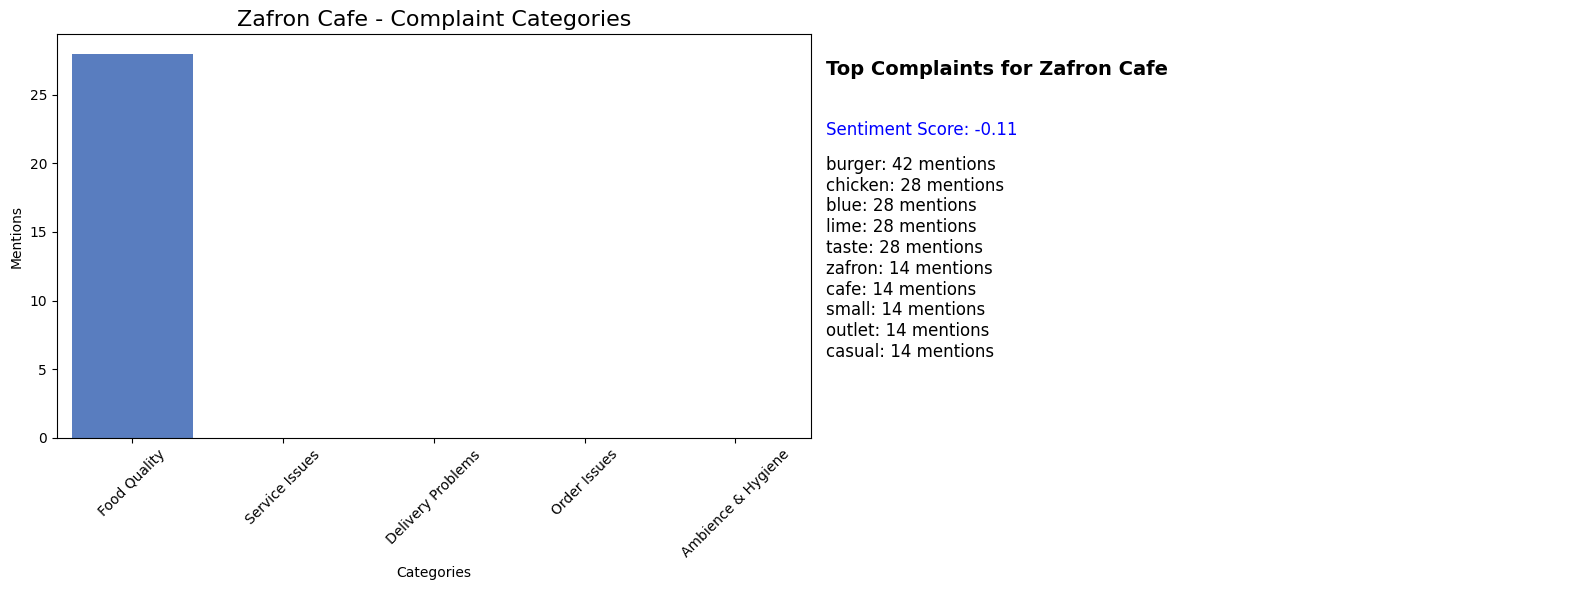

In [226]:
# Example usage
generate_restaurant_report('Zafron Cafe')


### Each restaurants can see their drawbacks and work upon it to improve their performance